# Personalized Learning Through Student Behavior Clustering Using ASSISTments Data

**Student Name:** Elias Abdulshaheed A.ameer Abbas \
**Topic:** Student Behavior Clustering for Personalized Learning \
**Cohort:** DSB-2 Full Time

# Introduction

This project uses interaction-level data from ASSISTments, an online tutoring platform used in K-12 math education, covering the 2009–2010 school year. Each row represents a single student's attempt at a problem, capturing not just whether the answer was correct, but *how* the student got there — number of attempts, hints requested, response time, and how much prior practice they'd had on that skill. Rather than predicting a single outcome, this project takes an unsupervised approach: grouping students into behavioral clusters based on how they engage with problems, with the goal of turning those raw interaction logs into interpretable learning personas that educators can act on.

# Problem Statement

Online learning platforms such as ASSISTments collect detailed information about student performance and learning behaviors. However, students have different learning needs, making it difficult for educators to provide personalized support.

This project aims to identify distinct student learning profiles based on performance, attempts, response time, hint usage, and practice behavior. These profiles will help educators better understand students' learning needs and provide targeted interventions, with the goal of improving student performance by 10%.

# Objectives
- What distinct behavioral patterns emerge among students when engaging with ASSISTments problems (e.g., accuracy, attempts, hint reliance, response speed, practice volume)?
- How many meaningful student clusters/personas exist in this behavioral feature space, and how well-separated are they?
- Do dimensionality reduction techniques (PCA) improve cluster quality or interpretability compared to clustering on raw features?
- Which clustering algorithm (K-Means, K-Means + PCA, GMM) best balances internal validation performance with interpretability for this dataset?
- What do the resulting clusters imply for personalized instructional intervention?

# Data Dictionary

| Feature | Data Type | Description |
|---------|----------|-------------|
| **order_id** | Integer | Chronological identifier of the student's interaction. Larger values indicate later interactions. |
| **assignment_id** | Integer | Unique identifier of the assignment (homework or activity) created by a teacher for a class. Different teachers can assign the same content but have different assignment IDs. |
| **user_id** | Integer | Unique identifier for each student. |
| **assistment_id** | Integer | Identifier of the ASSISTment (tutoring activity). One ASSISTment may contain multiple related problems or scaffold questions. |
| **problem_id** | Integer | Unique identifier for an individual problem. |
| **original** | Binary (0/1) | Indicates whether the problem is the original question (`1`) or a scaffold/help question (`0`). |
| **correct** | Binary (0/1) | Indicates whether the student answered correctly on the first attempt (`1`) or answered incorrectly/requested help (`0`). |
| **attempt_count** | Integer | Number of attempts the student made before completing the problem. |
| **ms_first_response** | Integer | Time (in milliseconds) between displaying the problem and the student's first response. |
| **tutor_mode** | Categorical | Learning mode during the interaction. Possible values include `tutor`and `test` |
| **answer_type** | Categorical | Type of expected answer (e.g., `choose_1`, `algebra`, `fill_in`, `open_response`). |
| **sequence_id** | Integer | Identifier of the problem set. Multiple assignments can share the same sequence if they use the same problem set. |
| **student_class_id** | Integer | Identifier of the student's classroom or class section. |
| **position** | Integer | Position of the assignment on the student's assignment page. |
| **problem_set_type** | Categorical | Organization of the problem set. Possible values include `Linear`, `Random`, and `Mastery`. |
| **base_sequence_id** | Integer | Identifier of the original sequence from which the current sequence was copied. If not copied, it is equal to `sequence_id`. |
| **skill_id** | Integer | Identifier of the mathematical skill associated with the problem. In the Skill Builder dataset, each row contains only one skill. Multi-skill problems are duplicated into multiple rows. |
| **skill_name** | String | Name of the mathematical skill associated with the problem. |
| **teacher_id** | Integer | Unique identifier of the teacher who assigned the problem. |
| **school_id** | Integer | Unique identifier of the school. |
| **hint_count** | Integer | Number of hints requested by the student while solving the problem. |
| **hint_total** | Integer | Total number of hints available for the problem. |
| **overlap_time** | Integer | Time (in milliseconds) representing overlapping student activity while interacting with the problem. |
| **template_id** | Integer | Identifier of the ASSISTment template. Problems sharing the same template have similar structures but different values. |
| **answer_id** | Integer | Identifier of the selected answer for multiple-choice questions. |
| **answer_text** | String | Student's submitted answer for fill-in or text-based questions. |
| **first_action** | Categorical | Student's first action after viewing the problem, such as `attempt`, `hint`, or `scaffolding`. |
| **bottom_hint** | Binary (0/1) | Indicates whether the student requested the bottom-out hint (the final hint revealing the solution). |
| **opportunity** | Integer | Number of previous opportunities the student has had to practice the associated skill. |
| **opportunity_original** | Integer | Number of previous opportunities the student has had to practice the skill considering only original problems (`original = 1`). |

---

# Feature Categories

| Category | Features |
|----------|----------|
| **Student Information** | `user_id`, `student_class_id`, `teacher_id`, `school_id` |
| **Assignment Information** | `assignment_id`, `sequence_id`, `base_sequence_id`, `position`, `problem_set_type` |
| **Problem Information** | `assistment_id`, `problem_id`, `template_id`, `original` |
| **Skill Information** | `skill_id`, `skill_name`, `opportunity`, `opportunity_original` |
| **Student Behavior** | `attempt_count`, `hint_count`, `hint_total`, `ms_first_response`, `overlap_time`, `first_action`, `bottom_hint` |
| **Response Information** | `correct`, `answer_type`, `answer_id`, `answer_text` |

---


In [1]:
# start you EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
# From Scikit-Learn (Best for fitting models and predicting cluster labels)
from sklearn.cluster import AgglomerativeClustering

# From SciPy (Best for creating and plotting dendrograms)
from scipy.cluster.hierarchy import dendrogram, linkage


In [2]:
# pip install numpy==2.2.6

# Data overview

Data Source : https://sites.google.com/site/assistmentsdata/home/2009-2010-assistment-data/skill-builder-data-2009-2010

In [3]:
df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')

C:\Users\elias\AppData\Local\Temp\ipykernel_17776\102637691.py:1: DtypeWarning: Columns (0: skill_id, 1: skill_name) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/skill_builder_data_corrected_collapsed.csv', encoding='latin-1')


In [4]:
pd.set_option('display.max_columns', None)

df.head()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [5]:
df.shape

(346860, 31)

In [6]:
df.columns

Index(['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id',
       'problem_id', 'original', 'correct', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id',
       'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id',
       'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total',
       'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='str')

In [7]:
df.head()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
4,5,35450311,220674,70363,33196,51481,1,0,14,19813,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,3,4,124564,30060,NaN,65,0,0.0,3,3.0


In [8]:
df.describe()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,sequence_id,student_class_id,position,base_sequence_id,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,first_action,bottom_hint,opportunity,opportunity_original
count,346860.000000,3.468600e+05,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,3.468600e+05,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,3.468600e+05,346860.000000,40042.000000,346860.000000,59857.000000,346860.000000,275458.000000
mean,211268.603659,3.060426e+07,273696.362801,83491.787026,47215.410728,82903.669028,0.794147,0.645269,1.638693,4.461290e+04,7360.590901,12922.895537,53.543686,6833.339771,47308.307020,3106.089200,0.509753,2.380638,5.739155e+04,39992.018249,146152.836297,0.126578,0.717243,22.236577,15.435170
std,117373.737194,5.256154e+06,11062.932570,7328.617764,11932.123078,25596.334242,0.404324,0.478432,12.146583,3.395273e+05,1515.334775,775.930104,62.064433,1291.511508,15569.791501,1835.708458,1.220223,1.781403,3.642423e+05,12971.149695,49056.621234,0.383373,0.450343,66.981549,67.931833
min,1.000000,2.022408e+07,217900.000000,14.000000,86.000000,83.000000,0.000000,0.000000,0.000000,-7.759575e+06,5870.000000,11644.000000,1.000000,5870.000000,11158.000000,1.000000,0.000000,0.000000,-7.759575e+06,86.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,108576.750000,2.652993e+07,266798.000000,78972.000000,37546.000000,59802.000000,1.000000,0.000000,1.000000,8.104000e+03,6018.000000,12352.000000,9.000000,5969.000000,42999.000000,2770.000000,0.000000,0.000000,1.028100e+04,30244.000000,104328.000000,0.000000,0.000000,3.000000,3.000000
50%,219002.500000,3.105405e+07,271631.000000,80223.000000,46773.000000,85101.000000,1.000000,1.000000,1.000000,1.834400e+04,6921.000000,12634.000000,25.000000,6181.000000,45778.000000,2770.000000,0.000000,3.000000,2.321800e+04,31006.000000,138528.000000,0.000000,1.000000,8.000000,6.000000
75%,312585.250000,3.485916e+07,279135.000000,88143.000000,53276.000000,93236.000000,1.000000,1.000000,1.000000,4.196900e+04,8439.000000,13241.000000,82.000000,7014.000000,59882.000000,5056.000000,0.000000,4.000000,5.447425e+04,47535.000000,198097.000000,0.000000,1.000000,20.000000,14.000000
max,401756.000000,3.831020e+07,291503.000000,96299.000000,106210.000000,207348.000000,1.000000,1.000000,3824.000000,8.407692e+07,13362.000000,14415.000000,295.000000,13362.000000,69274.000000,9948.000000,10.000000,10.000000,8.407692e+07,106180.000000,323181.000000,2.000000,1.000000,3371.000000,3371.000000


# Exploratory Data Analysis (EDA)

In [9]:
df['skill_name'].value_counts()

skill_name
Equation Solving Two or Fewer Steps         24253
Conversion of Fraction Decimals Percents    18742
Addition and Subtraction Integers           12741
Addition and Subtraction Fractions          11334
Equation Solving More Than Two Steps         8115
                                            ...  
Distributive Property                          18
Finding Slope From Situation                    9
Recognize Quadratic Pattern                     8
Reading a Ruler or Scale                        5
Finding Slope from Ordered Pairs                5
Name: count, Length: 101, dtype: int64

In [10]:
df['tutor_mode'].value_counts()

tutor_mode
tutor    346601
test        259
Name: count, dtype: int64

In [11]:
df['answer_type'].value_counts()

answer_type
algebra          270780
choose_1          41181
fill_in_1         34786
choose_n            105
open_response         8
Name: count, dtype: int64

In [12]:
df['first_action'].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [13]:
df['bottom_hint'].value_counts()

bottom_hint
1.0    42932
0.0    16925
Name: count, dtype: int64

In [14]:
df[df['bottom_hint'].isnull()]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
0,1,33022537,277618,64525,33139,51424,1,1,1,32454,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,32454,30799,NaN,26,0,NaN,1,1.0
1,2,33022709,277618,64525,33150,51435,1,1,1,4922,tutor,algebra,5948,13241,126,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4922,30799,NaN,55,0,NaN,2,2.0
2,3,35450204,220674,70363,33159,51444,1,0,2,25390,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,42000,30799,NaN,88,0,NaN,1,1.0
3,4,35450295,220674,70363,33110,51395,1,1,1,4859,tutor,algebra,5948,11816,22,MasterySection,5948,1_13,Box and Whisker,22763,73,0,3,4859,30059,NaN,41,0,NaN,2,2.0
5,6,35450555,220674,70363,33172,51457,1,1,1,16031,tutor,algebra,5948,11816,22,MasterySection,5948,1_15,Box and Whisker,22763,73,0,4,16031,30060,NaN,12,0,NaN,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346854,401751,38214011,291495,96299,57822,108953,0,1,1,3375,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,1,3375,55691,200237.0,NaN,0,NaN,53,NaN
346855,401752,38214014,291495,96299,57830,108976,0,1,1,38234,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,2,38234,55692,200260.0,NaN,0,NaN,54,NaN
346856,401753,38214016,291495,96299,57843,109015,0,1,1,6500,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,6500,55693,200299.0,NaN,0,NaN,55,NaN
346857,401754,38214195,291503,96299,34577,54060,0,1,1,18344,tutor,algebra,5962,14415,16,MasterySection,5962,NaN,NaN,69274,2770,0,3,18344,30677,NaN,0.8,0,NaN,56,NaN


In [15]:
df[(df['bottom_hint'].isnull())&
    (df['hint_count']>=1)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original


In [16]:
df[
    (df['correct'] == 1) &
    (df['attempt_count'] == 3)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
6682,6683,30145384,270288,79018,53495,93466,1,1,3,10462,tutor,algebra,7118,12351,149,MasterySection,7118,2_37_48_77,Circle Graph,42999,2770,0,3,10462,52571,NaN,72,0,NaN,3,3.0
6931,6932,30062521,270288,79033,53491,93462,1,1,3,24948,tutor,algebra,7118,12351,149,MasterySection,7118,2_37_48_77,Circle Graph,42999,2770,0,3,24948,52571,NaN,30,0,NaN,3,3.0
9679,9680,38290132,291366,96262,53495,93466,1,1,3,10462,tutor,algebra,7118,14415,147,MasterySection,7118,2_37_48_77,Circle Graph,69274,2770,0,3,10462,52571,NaN,72,0,NaN,2,2.0
9879,9880,38300582,291366,96275,53491,93462,1,1,3,24948,tutor,algebra,7118,14415,147,MasterySection,7118,2_37_48_77,Circle Graph,69274,2770,0,3,24948,52571,NaN,30,0,NaN,6,6.0
33712,38110,22991076,265503,82341,51815,91139,1,1,3,49441,tutor,algebra,7035,12507,5,MasterySection,7035,13,Median,43015,2770,0,3,49441,50237,NaN,39,0,NaN,3,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339055,393952,38277412,290921,96232,57424,107958,0,1,3,4646,tutor,choose_1,5969,14414,71,MasterySection,5969,NaN,NaN,69274,2770,0,0,4646,55834,198523.0,NaN,0,NaN,141,NaN
340978,395875,38215134,291495,96253,57837,108997,0,1,3,26206,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,26206,55693,200281.0,NaN,0,NaN,97,NaN
341392,396289,38164569,291495,96257,57836,108995,0,1,3,8990,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,8990,55693,200279.0,NaN,0,NaN,69,NaN
342988,397885,38225650,291495,96272,57811,108920,0,1,3,30861,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,30861,55690,200204.0,NaN,0,NaN,19,NaN


In [17]:
df[
    (df['attempt_count'] == 0)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
2769,2770,35230695,281135,89485,33181,51466,1,0,0,2415,tutor,algebra,5948,13638,2,MasterySection,5948,1_15,Box and Whisker,28420,5497,3,4,10261,30060,NaN,NaN,1,0.0,2,2.0
2790,2791,35231377,281135,91253,33167,51452,1,0,0,11301,tutor,algebra,5948,13638,2,MasterySection,5948,1_15,Box and Whisker,28420,4780,1,4,11301,30060,NaN,NaN,1,0.0,2,2.0
3964,3965,21617692,263600,14,36838,57695,1,0,0,59891,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,59891,30397,NaN,NaN,2,NaN,8,8.0
3966,3967,21617749,263600,14,36822,57647,1,0,0,82572,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,82572,30397,NaN,NaN,2,NaN,10,10.0
3968,3969,21617825,263600,14,37068,58551,1,0,0,27225,tutor,algebra,5916,12495,2,MasterySection,5916,2_37_48_77,Circle Graph,42972,1,0,0,27225,30790,NaN,NaN,2,NaN,12,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336872,391769,38263339,290585,96216,73507,136020,1,0,0,9443,tutor,fill_in_1,9911,14412,53,MasterySection,9911,NaN,NaN,69274,2770,2,2,10848,73252,NaN,NaN,1,1.0,174,95.0
342569,397466,38156420,291355,96268,41964,74344,0,0,0,40653,tutor,fill_in_1,6109,14415,157,MasterySection,6094,NaN,NaN,69274,2770,1,3,40653,31062,NaN,NaN,1,0.0,2,NaN
343367,398264,38184469,291368,96274,32170,49355,1,0,0,2735,tutor,algebra,5925,14415,141,MasterySection,5925,NaN,NaN,69274,2770,0,0,2735,30036,NaN,NaN,2,NaN,187,1.0
345850,400747,38143088,290662,96291,74233,137844,1,0,0,64048,tutor,algebra,9882,14413,35,MasterySection,9882,NaN,NaN,69274,2770,0,0,64048,58782,NaN,NaN,2,NaN,60,46.0


In [18]:
df[(df['hint_total']==0)&
    (df['hint_count']==0)&
    (df['bottom_hint'].isnull())    
][['correct', 'attempt_count', 'hint_count', 'hint_total', 'bottom_hint']]

,correct,attempt_count,hint_count,hint_total,bottom_hint
162,1,1,0,0,NaN
200,1,1,0,0,NaN
211,1,1,0,0,NaN
280,0,2,0,0,NaN
285,1,1,0,0,NaN
...,...,...,...,...,...
346802,0,2,0,0,NaN
346803,1,1,0,0,NaN
346852,1,1,0,0,NaN
346853,1,2,0,0,NaN


In [19]:
df[(df['hint_total'] > 0) & (df['bottom_hint'].isnull())][['correct', 'attempt_count', 'hint_count', 'hint_total', 'bottom_hint']]


,correct,attempt_count,hint_count,hint_total,bottom_hint
0,1,1,0,3,NaN
1,1,1,0,3,NaN
2,0,2,0,3,NaN
3,1,1,0,3,NaN
5,1,1,0,4,NaN
...,...,...,...,...,...
346851,0,2,0,5,NaN
346854,1,1,0,1,NaN
346855,1,1,0,2,NaN
346857,1,1,0,3,NaN


In [20]:
df[df['bottom_hint'].isnull()][
    ['hint_count', 'hint_total']
].value_counts().head(30)

##Therefore, filling bottom_hint with 0 is reasonable

hint_count  hint_total
0           0             101551
            3              69124
            4              51682
            2              35358
            5              20836
            1               4305
            6               3058
            7                907
            8                180
            10                 2
Name: count, dtype: int64

In [21]:
df["first_action"].value_counts()

first_action
0    309271
1     31273
2      6316
Name: count, dtype: int64

In [22]:
df[df["first_action"] == 2].head(20)

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
3964,3965,21617692,263600,14,36838,57695,1,0,0,59891,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,59891,30397,NaN,NaN,2,NaN,8,8.0
3966,3967,21617749,263600,14,36822,57647,1,0,0,82572,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,82572,30397,NaN,NaN,2,NaN,10,10.0
3968,3969,21617825,263600,14,37068,58551,1,0,0,27225,tutor,algebra,5916,12495,2,MasterySection,5916,2_37_48_77,Circle Graph,42972,1,0,0,27225,30790,NaN,NaN,2,NaN,12,12.0
3983,3984,35305686,220655,70363,31403,47081,1,0,0,55499,tutor,algebra,5898,11816,3,MasterySection,5898,2_70,Circle Graph,22763,73,0,0,55499,30038,NaN,NaN,2,NaN,2,2.0
3986,3987,35307058,220655,70363,36823,57650,1,0,0,35562,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,35562,30397,NaN,NaN,2,NaN,5,5.0
4070,4071,30319263,220665,70872,37067,58548,1,0,0,13498,tutor,algebra,5916,11816,13,MasterySection,5916,2_37_48,Circle Graph,22763,73,0,0,13498,30790,NaN,NaN,2,NaN,1,1.0
4071,4072,30319442,220665,70872,36820,57641,1,0,0,32280,tutor,algebra,5916,11816,13,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,32280,30397,NaN,NaN,2,NaN,2,2.0
4136,4137,20432779,232255,71826,36838,57695,1,0,0,250201,tutor,algebra,5898,11971,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,250201,30397,NaN,NaN,2,NaN,2,2.0
4144,4145,20427027,220655,71877,36843,57710,1,0,0,75467,tutor,algebra,5898,11816,3,MasterySection,5898,2_48_79,Circle Graph,22763,73,0,0,75467,30397,NaN,NaN,2,NaN,2,2.0
4156,4157,35455538,277620,71881,36822,57647,1,0,0,1131591,tutor,algebra,5916,13241,128,MasterySection,5916,2_48_79,Circle Graph,22763,73,0,0,1131591,30397,NaN,NaN,2,NaN,9,9.0


In [23]:
df[df["first_action"] == 2][[
    "correct",
    "attempt_count",
    "hint_count",
    "hint_total",
    "answer_type",
    "tutor_mode"
]].describe(include="all")

,correct,attempt_count,hint_count,hint_total,answer_type,tutor_mode
count,6316.0,6316.000000,6316.0,6316.000000,6316,6316
unique,NaN,NaN,NaN,NaN,3,1
top,NaN,NaN,NaN,NaN,algebra,tutor
freq,NaN,NaN,NaN,NaN,5979,6316
mean,0.0,0.008708,0.0,0.131096,NaN,NaN
std,0.0,0.140422,0.0,0.613319,NaN,NaN
min,0.0,0.000000,0.0,0.000000,NaN,NaN
25%,0.0,0.000000,0.0,0.000000,NaN,NaN
50%,0.0,0.000000,0.0,0.000000,NaN,NaN
75%,0.0,0.000000,0.0,0.000000,NaN,NaN


In [24]:
# 1. Group by user_id and problem_id, then count occurrences
counts = df.groupby(['user_id', 'problem_id']).size().reset_index(name='count')

# 2. Filter to keep only those with more than 1 record for the same problem_id
duplicates = counts[counts['count'] > 1]

print(duplicates)

        user_id  problem_id  count
88        53167       53613      2
144       53167       57051      2
423       64525       49286      2
428       64525       49331      2
439       64525       49379      2
...         ...         ...    ...
341573    96298      107974      2
341601    96298      108132      2
341602    96298      108133      2
341621    96298      108253      2
342040    96299      108000      2

[4599 rows x 3 columns]


In [25]:
# 1. Filter original DataFrame to get all matching rows with all columns
full_records = df[df.duplicated(subset=['user_id', 'problem_id'], keep=False)]

# 2. Sort to easily view attempts side-by-side
full_records = full_records.sort_values(by=['user_id', 'problem_id'])

# 3. Force pandas to display all columns and a higher row limit
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Display the DataFrame
display(full_records)

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
108195,136931,26452685,263411,53167,34308,53613,1,1,1,8265,tutor,algebra,5959,12482,1,MasterySection,5959,58_85,Addition Whole Numbers,22763,73,0,0,8265,30524,NaN,16,0,NaN,4,4.0
108198,136934,32513894,277494,53167,34308,53613,1,1,1,9484,tutor,algebra,5959,13241,2,MasterySection,5959,58_85,Addition Whole Numbers,22763,73,0,0,9484,30524,NaN,16,0,NaN,7,7.0
19564,19565,26451283,263406,53167,36567,57051,1,1,1,33539,tutor,algebra,5933,12481,10,MasterySection,5933,10_14,Table,22763,73,0,0,33539,30375,NaN,10,0,NaN,7,7.0
19569,19570,35128429,277631,53167,36567,57051,1,1,1,12110,tutor,algebra,5933,13241,139,MasterySection,5933,10_14,Table,22763,73,0,0,12110,30375,NaN,10,0,NaN,12,12.0
108207,136943,28177219,270542,64525,32143,49286,1,1,1,44933,tutor,fill_in_1,5924,11816,116,MasterySection,5924,58,Addition Whole Numbers,22763,73,0,4,44933,30336,NaN,201,0,NaN,4,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271629,324070,38175514,291429,96298,57465,108133,0,0,21,13573,tutor,algebra,5969,14415,82,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,30146,55833,NaN,-67\,0,NaN,55,NaN
271606,324047,38175246,291449,96298,57490,108253,1,1,1,43180,tutor,algebra,5969,14415,62,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,43180,55836,NaN,-0.008928571,0,NaN,32,17.0
271630,324071,38175515,291429,96298,57490,108253,1,1,1,44757,tutor,algebra,5969,14415,82,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,44757,55836,NaN,-0.008928571,0,NaN,56,31.0
271658,324099,38213636,291449,96299,57433,108000,1,0,1,72546,tutor,algebra,5969,14415,62,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,72609,55835,NaN,1/100,0,NaN,20,9.0


In [26]:
full_records[full_records['user_id']== 96298]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
263435,315876,38175367,291430,96298,55613,97735,1,1,1,27296,tutor,algebra,5968,14415,81,MasterySection,5968,311.0,Equation Solving Two or Fewer Steps,69274,2770,0,3,27296,54697,NaN,-0.818181818,0,NaN,31,19.0
263450,315891,38175455,291450,96298,55613,97735,1,1,1,176756,tutor,algebra,5968,14415,61,MasterySection,5968,311.0,Equation Solving Two or Fewer Steps,69274,2770,0,3,176756,54697,NaN,-0.818181818,0,NaN,46,31.0
271623,324064,38175269,291449,96298,57410,107885,1,1,1,186565,tutor,algebra,5969,14415,62,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,186565,55833,NaN,-6.666666667,0,NaN,49,28.0
271631,324072,38175516,291429,96298,57410,107885,1,1,1,34516,tutor,algebra,5969,14415,82,MasterySection,5969,312.0,Equation Solving More Than Two Steps,69274,2770,0,0,34516,55833,NaN,-6.666666667,0,NaN,57,32.0
179372,230593,38175243,291449,96298,57427,107970,1,0,1,40055,tutor,algebra,5969,14415,62,MasterySection,5969,101,NaN,69274,2770,0,0,40103,55834,NaN,8/-35,0,NaN,4,4.0
179378,230599,38175513,291429,96298,57427,107970,1,0,1,76586,tutor,algebra,5969,14415,82,MasterySection,5969,101,NaN,69274,2770,0,0,76593,55834,NaN,36/21,0,NaN,10,10.0
346754,401651,38175248,291449,96298,57427,107972,0,1,1,14204,tutor,choose_1,5969,14415,62,MasterySection,5969,NaN,NaN,69274,2770,0,0,14204,55834,198540.0,NaN,0,NaN,6,NaN
346775,401672,38175520,291429,96298,57427,107972,0,1,1,8012,tutor,choose_1,5969,14415,82,MasterySection,5969,NaN,NaN,69274,2770,0,0,8012,55834,198540.0,NaN,0,NaN,27,NaN
346753,401650,38175245,291449,96298,57427,107973,0,1,1,9360,tutor,choose_1,5969,14415,62,MasterySection,5969,NaN,NaN,69274,2770,0,0,9360,55834,198541.0,NaN,0,NaN,5,NaN
346773,401670,38175511,291429,96298,57427,107973,0,1,1,9496,tutor,choose_1,5969,14415,82,MasterySection,5969,NaN,NaN,69274,2770,0,0,9496,55834,198541.0,NaN,0,NaN,25,NaN


In [27]:
df[(df['user_id']==64525) &
   (df['attempt_count'] > 1)
    ]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
3972,3973,33022751,277619,64525,53461,93432,1,0,5,57056,tutor,algebra,7118,13241,127,MasterySection,7118,2_37_48_77,Circle Graph,22763,73,3,3,125923,52571,NaN,17,0,1.0,4,4.0
39973,51744,33023987,277622,64525,53817,93788,1,0,3,75371,tutor,algebra,7123,13241,130,MasterySection,7123,17,Probability of Two Distinct Events,22763,73,4,4,270301,52609,NaN,Jan-32,0,1.0,1,1.0
53993,71285,32413897,277557,64525,43817,79115,1,0,3,105737,tutor,choose_1,6408,13241,65,MasterySection,6408,27,Pythagorean Theorem,22763,73,2,4,237291,42201,135766.0,NaN,0,0.0,1,1.0
53995,71287,32422907,277557,64525,43879,79177,1,0,2,41012,tutor,choose_1,6408,13241,65,MasterySection,6408,27,Pythagorean Theorem,22763,73,0,2,45337,42284,136146.0,NaN,0,NaN,3,3.0
53997,71289,32423404,277557,64525,43883,79181,1,0,2,36558,tutor,choose_1,6408,13241,65,MasterySection,6408,27,Pythagorean Theorem,22763,73,0,3,40584,42284,136162.0,NaN,0,NaN,5,5.0
53998,71290,32423465,277557,64525,43806,79104,1,0,2,33868,tutor,choose_1,6408,13241,65,MasterySection,6408,27,Pythagorean Theorem,22763,73,0,4,42415,41554,135704.0,NaN,0,NaN,6,6.0
54000,71292,32424140,277559,64525,43909,79207,1,0,3,72340,tutor,choose_1,6409,13241,67,MasterySection,6409,27,Pythagorean Theorem,22763,73,0,3,97419,42215,136261.0,NaN,0,NaN,8,8.0
54002,71294,32424298,277559,64525,43945,79243,1,0,2,899889,tutor,choose_1,6409,13241,67,MasterySection,6409,27,Pythagorean Theorem,22763,73,0,3,909648,42285,136370.0,NaN,0,NaN,10,10.0
54004,71296,32424777,277559,64525,43905,79203,1,0,3,16610,tutor,choose_1,6409,13241,67,MasterySection,6409,27,Pythagorean Theorem,22763,73,0,3,21459,42215,136249.0,NaN,0,NaN,12,12.0
54012,71304,32425755,277563,64525,44306,80044,1,0,2,2581,tutor,fill_in_1,6467,13241,71,MasterySection,6467,27,Pythagorean Theorem,22763,73,0,5,4215,42087,NaN,1,0,NaN,20,20.0


In [28]:
# df = df[
#     (df['correct'] != 1) |
#     (df['attempt_count'] <= 1)
# ].copy()

In [29]:
df.columns

Index(['Unnamed: 0', 'order_id', 'assignment_id', 'user_id', 'assistment_id',
       'problem_id', 'original', 'correct', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'answer_type', 'sequence_id',
       'student_class_id', 'position', 'type', 'base_sequence_id', 'skill_id',
       'skill_name', 'teacher_id', 'school_id', 'hint_count', 'hint_total',
       'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'bottom_hint', 'opportunity', 'opportunity_original'],
      dtype='str')

In [30]:
df[(df['correct']==0) &
   (df['attempt_count'] == 1)
    ]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
86,87,35529344,282727,71225,33155,51440,1,0,1,15613,tutor,algebra,5948,12473,1,MasterySection,5948,1_13,Box and Whisker,24116,76,3,3,25568,30799,NaN,NaN,1,1.0,2,2.0
153,154,29980929,270287,78073,33161,51446,1,0,1,21706,tutor,algebra,5948,12351,148,MasterySection,5948,1_13,Box and Whisker,42999,2770,2,3,35203,30799,NaN,NaN,1,0.0,1,1.0
155,156,29981041,270287,78073,33190,51475,1,0,1,11790,tutor,algebra,5948,12351,148,MasterySection,5948,1_15,Box and Whisker,42999,2770,2,4,44398,30060,NaN,NaN,1,0.0,3,3.0
197,198,30946454,271963,78905,73224,135649,1,0,1,17810,tutor,algebra,9879,12886,30,MasterySection,9879,1,Box and Whisker,42999,2770,2,2,27884,63446,NaN,NaN,1,1.0,1,1.0
219,220,30947580,271980,78907,33121,51406,1,0,1,11181,tutor,algebra,9875,12885,30,MasterySection,9875,1_13,Box and Whisker,42999,2770,1,3,16977,30059,NaN,NaN,1,0.0,2,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346845,401742,38213917,291481,96299,38385,61692,0,0,1,2984,tutor,fill_in_1,6022,14415,45,MasterySection,6022,NaN,NaN,69274,2770,3,3,7640,30488,NaN,NaN,1,1.0,44,NaN
346846,401743,38213918,291481,96299,38350,61588,0,0,1,1468,tutor,algebra,6022,14415,45,MasterySection,6022,NaN,NaN,69274,2770,5,5,9218,30482,NaN,NaN,1,1.0,45,NaN
346847,401744,38213920,291481,96299,38311,61470,0,0,1,2015,tutor,fill_in_1,6022,14415,45,MasterySection,6022,NaN,NaN,69274,2770,3,3,7468,30306,NaN,NaN,1,1.0,46,NaN
346848,401745,38213921,291481,96299,38311,61471,0,0,1,1641,tutor,algebra,6022,14415,45,MasterySection,6022,NaN,NaN,69274,2770,5,5,8735,30306,NaN,NaN,1,1.0,47,NaN


In [31]:
df[(df['correct']==1) &
   (df['attempt_count'] == 0)
    ]

## Already all of records has illogical ms_first_response (1000ms>x)

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
26787,26788,35103624,280998,78492,53245,93205,1,1,0,1,tutor,algebra,7228,12375,24,MasterySection,7114,11,Venn Diagram,46174,5056,0,2,1,52497,NaN,19,0,NaN,105,105.0
26790,26791,35103796,280998,78493,53267,93227,1,1,0,0,tutor,algebra,7228,12375,24,MasterySection,7114,11,Venn Diagram,46174,5056,0,2,0,52497,NaN,18,0,NaN,53,53.0
26793,26794,35103590,280998,78494,53224,93184,1,1,0,1,tutor,algebra,7228,12375,24,MasterySection,7114,11,Venn Diagram,46174,5056,0,2,1,52495,NaN,6,0,NaN,53,53.0
26798,26799,35105809,280998,78495,53190,93150,1,1,0,0,tutor,algebra,7228,12375,24,MasterySection,7114,11,Venn Diagram,46174,5056,0,2,0,52495,NaN,6,0,NaN,105,105.0
26801,26802,35104213,280998,78498,53230,93190,1,1,0,0,tutor,algebra,7228,12375,24,MasterySection,7114,11,Venn Diagram,46174,5056,0,2,0,52495,NaN,4,0,NaN,53,53.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280413,333416,36547605,286173,92250,85759,162095,1,1,0,0,tutor,choose_1,10293,14020,118,MasterySection,10293,362.0,"Parts of a Polyomial, Terms, Coefficient, Mono...",58932,4780,0,3,0,62323,300529.0,NaN,0,NaN,191,141.0
280417,333420,36468041,285991,92251,85779,162115,1,1,0,0,tutor,choose_1,10293,14020,62,MasterySection,10293,362.0,"Parts of a Polyomial, Terms, Coefficient, Mono...",58932,4780,0,3,0,62324,300608.0,NaN,0,NaN,76,76.0
280418,333421,36487945,286018,92251,59947,114230,1,1,0,0,tutor,choose_n,10293,14020,85,MasterySection,10293,362.0,"Parts of a Polyomial, Terms, Coefficient, Mono...",58932,4780,0,0,0,58275,1.0,NaN,0,NaN,80,80.0
280419,333422,36527518,286131,92251,85776,162112,1,1,0,0,tutor,choose_1,10293,14020,103,MasterySection,10293,362.0,"Parts of a Polyomial, Terms, Coefficient, Mono...",58932,4780,0,3,0,62324,300596.0,NaN,0,NaN,82,82.0


In [32]:
df[(df['correct'] == 0) &
    (df['attempt_count'] == 0)
    ]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
2769,2770,35230695,281135,89485,33181,51466,1,0,0,2415,tutor,algebra,5948,13638,2,MasterySection,5948,1_15,Box and Whisker,28420,5497,3,4,10261,30060,NaN,NaN,1,0.0,2,2.0
2790,2791,35231377,281135,91253,33167,51452,1,0,0,11301,tutor,algebra,5948,13638,2,MasterySection,5948,1_15,Box and Whisker,28420,4780,1,4,11301,30060,NaN,NaN,1,0.0,2,2.0
3964,3965,21617692,263600,14,36838,57695,1,0,0,59891,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,59891,30397,NaN,NaN,2,NaN,8,8.0
3966,3967,21617749,263600,14,36822,57647,1,0,0,82572,tutor,algebra,5916,12495,2,MasterySection,5916,2_48_79,Circle Graph,42972,1,0,0,82572,30397,NaN,NaN,2,NaN,10,10.0
3968,3969,21617825,263600,14,37068,58551,1,0,0,27225,tutor,algebra,5916,12495,2,MasterySection,5916,2_37_48_77,Circle Graph,42972,1,0,0,27225,30790,NaN,NaN,2,NaN,12,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336872,391769,38263339,290585,96216,73507,136020,1,0,0,9443,tutor,fill_in_1,9911,14412,53,MasterySection,9911,NaN,NaN,69274,2770,2,2,10848,73252,NaN,NaN,1,1.0,174,95.0
342569,397466,38156420,291355,96268,41964,74344,0,0,0,40653,tutor,fill_in_1,6109,14415,157,MasterySection,6094,NaN,NaN,69274,2770,1,3,40653,31062,NaN,NaN,1,0.0,2,NaN
343367,398264,38184469,291368,96274,32170,49355,1,0,0,2735,tutor,algebra,5925,14415,141,MasterySection,5925,NaN,NaN,69274,2770,0,0,2735,30036,NaN,NaN,2,NaN,187,1.0
345850,400747,38143088,290662,96291,74233,137844,1,0,0,64048,tutor,algebra,9882,14413,35,MasterySection,9882,NaN,NaN,69274,2770,0,0,64048,58782,NaN,NaN,2,NaN,60,46.0


In [33]:
problem = df[
    (df['correct'] == 1) &
    (df['attempt_count'] == 0)
]

problem['answer_type'].value_counts(dropna=False)

answer_type
algebra      538
fill_in_1     28
choose_1      19
choose_n      10
Name: count, dtype: int64

In [34]:
problem = df[
    (df['correct'] == 1) &
    (df['attempt_count'] == 0)
]

problem.groupby(
    ['original', 'first_action', 'answer_type'],
    dropna=False
).agg(
    rows=('user_id', 'size'),
    students=('user_id', 'nunique'),
    problems=('problem_id', 'nunique'),
    avg_response_time=('ms_first_response', 'mean'),
    median_response_time=('ms_first_response', 'median'),
    avg_hints=('hint_count', 'mean')
).sort_values(
    'rows',
    ascending=False
)

rows  students  problems  \
original first_action answer_type                             
1        0            algebra       538       107       387   
                      fill_in_1      28         9        24   
                      choose_1       19         7        16   
                      choose_n       10         5        10   

                                   avg_response_time  median_response_time  \
original first_action answer_type                                            
1        0            algebra               2.031599                   1.0   
                      fill_in_1             2.571429                   2.0   
                      choose_1              0.736842                   1.0   
                      choose_n              0.700000                   1.0   

                                   avg_hints  
original first_action answer_type             
1        0            algebra            0.0  
                      fill_in_1          0.0  
                      choose_1           0.0  
                      choose_n           0.0

In [35]:
problem = df[
    (df['correct'] == 0) &
    (df['attempt_count'] == 0)
]

problem.groupby(
    ['original', 'first_action', 'answer_type'],
    dropna=False
).agg(
    rows=('user_id', 'size'),
    students=('user_id', 'nunique'),
    problems=('problem_id', 'nunique'),
    avg_response_time=('ms_first_response', 'mean'),
    median_response_time=('ms_first_response', 'median'),
    avg_hints=('hint_count', 'mean')
).sort_values(
    'rows',
    ascending=False
)

rows  students  problems  \
original first_action answer_type                             
1        2            algebra      5946      1177      1626   
                      fill_in_1     274       147       101   
         1            algebra       174       148       171   
         2            choose_1       59        32        54   
0        1            algebra        48        44        45   
1        0            algebra        39        13        39   
         1            fill_in_1      33        29        30   
0        1            fill_in_1      15        13        12   
                      choose_1       13        11        13   
1        1            choose_1        5         4         5   
         0            choose_1        4         2         4   
0        2            fill_in_1       4         4         1   
1        0            choose_n        2         1         2   
                      fill_in_1       2         2         2   

                                   avg_response_time  median_response_time  \
original first_action answer_type                                            
1        2            algebra           49066.137908               11297.0   
                      fill_in_1        175487.080292               28118.5   
         1            algebra           58706.614943               12264.5   
         2            choose_1          38182.915254               15722.0   
0        1            algebra           10765.604167                5881.5   
1        0            algebra               1.487179                   1.0   
         1            fill_in_1         57784.424242               17496.0   
0        1            fill_in_1         19656.000000                6830.0   
                      choose_1          28713.538462               14453.0   
1        1            choose_1          10581.800000                4375.0   
         0            choose_1              0.500000                   0.5   
0        2            fill_in_1          3395.250000                2133.0   
1        0            choose_n              1.000000                   1.0   
                      fill_in_1             1.000000                   1.0   

                                   avg_hints  
original first_action answer_type             
1        2            algebra       0.000000  
                      fill_in_1     0.000000  
         1            algebra       1.879310  
         2            choose_1      0.000000  
0        1            algebra       1.875000  
1        0            algebra       0.000000  
         1            fill_in_1     2.848485  
0        1            fill_in_1     2.066667  
                      choose_1      2.153846  
1        1            choose_1      2.800000  
         0            choose_1      0.000000  
0        2            fill_in_1     0.000000  
1        0            choose_n      0.000000  
                      fill_in_1     0.000000

In [36]:
df[
    (df['ms_first_response'] <= 1000)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
4359,4360,29387604,265375,77957,53494,93465,1,0,1,969,tutor,algebra,7229,12438,6,MasterySection,7118,2_37_48_77,Circle Graph,23907,76,3,3,14167,52571,NaN,NaN,1,1.0,58,58.0
10859,10860,35397005,281860,79026,33038,51323,1,1,1,-7759575,tutor,fill_in_1,5947,12351,222,MasterySection,5947,4,Histogram as Table or Graph,42999,2770,0,4,-7759575,32148,NaN,75,0,NaN,8,8.0
17609,17610,30088875,270943,81457,73194,135619,1,0,1,469,tutor,algebra,9085,12872,21,MasterySection,9085,9_14,Stem and Leaf Plot,45671,5049,2,2,90906,63444,NaN,NaN,1,1.0,1,1.0
24613,24614,35247638,281103,88589,32021,48881,1,0,0,936,tutor,algebra,5921,13601,4,MasterySection,5921,10_12,Table,60450,5448,0,0,936,30244,NaN,NaN,2,NaN,17,17.0
24618,24619,35248213,281103,88589,32037,49000,1,0,0,949,tutor,algebra,5921,13601,4,MasterySection,5921,10_12,Table,60450,5448,0,0,949,30244,NaN,NaN,2,NaN,22,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345743,400640,38255029,290583,96290,73573,136086,1,0,1,891,tutor,fill_in_1,9913,14412,55,MasterySection,9913,NaN,NaN,69274,2770,2,2,8594,73258,NaN,NaN,1,1.0,124,73.0
345745,400642,38255031,290583,96290,73527,136040,1,0,1,891,tutor,fill_in_1,9913,14412,55,MasterySection,9913,NaN,NaN,69274,2770,2,2,11625,73254,NaN,NaN,1,1.0,126,75.0
346054,400951,38220459,290765,96292,41726,73553,0,0,1,929,tutor,fill_in_1,6094,14414,230,MasterySection,6094,NaN,NaN,69274,2770,4,4,6616,30421,NaN,NaN,1,1.0,151,NaN
346706,401603,38162377,290822,96297,44699,81197,0,0,1,858,tutor,algebra,6467,14414,169,MasterySection,6467,NaN,NaN,69274,2770,5,5,53505,42088,NaN,NaN,1,1.0,83,NaN


In [37]:
df[
    (df['original'] == 0)
]

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,tutor_mode,answer_type,sequence_id,student_class_id,position,type,base_sequence_id,skill_id,skill_name,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,answer_text,first_action,bottom_hint,opportunity,opportunity_original
41202,55412,28239445,270186,79586,74895,139572,0,0,31,21078,tutor,fill_in_1,9222,12768,16,MasterySection,9222,17,Probability of Two Distinct Events,45671,5049,0,2,124594,30419,NaN,2,0,NaN,6,NaN
41203,55413,28239578,270186,79586,74895,139573,0,0,3,4391,tutor,fill_in_1,9222,12768,16,MasterySection,9222,17,Probability of Two Distinct Events,45671,5049,0,4,25891,30419,NaN,2,0,NaN,7,NaN
41204,55414,28239607,270186,79586,74895,139574,0,1,1,26610,tutor,algebra,9222,12768,16,MasterySection,9222,17,Probability of Two Distinct Events,45671,5049,0,4,26610,30419,NaN,25-May,0,NaN,8,NaN
41207,55417,28240204,270186,79586,74881,139503,0,1,1,54360,tutor,choose_1,9222,12768,16,MasterySection,9222,17,Probability of Two Distinct Events,45671,5049,0,1,54360,58408,256392.0,NaN,0,NaN,11,NaN
41208,55418,28240280,270186,79586,74881,139504,0,1,1,4281,tutor,algebra,9222,12768,16,MasterySection,9222,17,Probability of Two Distinct Events,45671,5049,0,3,4281,58408,NaN,Apr-49,0,NaN,12,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346855,401752,38214014,291495,96299,57830,108976,0,1,1,38234,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,2,38234,55692,200260.0,NaN,0,NaN,54,NaN
346856,401753,38214016,291495,96299,57843,109015,0,1,1,6500,tutor,choose_1,6009,14415,39,MasterySection,6009,NaN,NaN,69274,2770,0,0,6500,55693,200299.0,NaN,0,NaN,55,NaN
346857,401754,38214195,291503,96299,34577,54060,0,1,1,18344,tutor,algebra,5962,14415,16,MasterySection,5962,NaN,NaN,69274,2770,0,3,18344,30677,NaN,0.8,0,NaN,56,NaN
346858,401755,38214196,291503,96299,34577,54061,0,1,1,12922,tutor,algebra,5962,14415,16,MasterySection,5962,NaN,NaN,69274,2770,0,2,12922,30677,NaN,-6,0,NaN,57,NaN


In [38]:
df.shape

(346860, 31)

In [39]:
df.describe()

,Unnamed: 0,order_id,assignment_id,user_id,assistment_id,problem_id,original,correct,attempt_count,ms_first_response,sequence_id,student_class_id,position,base_sequence_id,teacher_id,school_id,hint_count,hint_total,overlap_time,template_id,answer_id,first_action,bottom_hint,opportunity,opportunity_original
count,346860.000000,3.468600e+05,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,3.468600e+05,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,346860.000000,3.468600e+05,346860.000000,40042.000000,346860.000000,59857.000000,346860.000000,275458.000000
mean,211268.603659,3.060426e+07,273696.362801,83491.787026,47215.410728,82903.669028,0.794147,0.645269,1.638693,4.461290e+04,7360.590901,12922.895537,53.543686,6833.339771,47308.307020,3106.089200,0.509753,2.380638,5.739155e+04,39992.018249,146152.836297,0.126578,0.717243,22.236577,15.435170
std,117373.737194,5.256154e+06,11062.932570,7328.617764,11932.123078,25596.334242,0.404324,0.478432,12.146583,3.395273e+05,1515.334775,775.930104,62.064433,1291.511508,15569.791501,1835.708458,1.220223,1.781403,3.642423e+05,12971.149695,49056.621234,0.383373,0.450343,66.981549,67.931833
min,1.000000,2.022408e+07,217900.000000,14.000000,86.000000,83.000000,0.000000,0.000000,0.000000,-7.759575e+06,5870.000000,11644.000000,1.000000,5870.000000,11158.000000,1.000000,0.000000,0.000000,-7.759575e+06,86.000000,1.000000,0.000000,0.000000,1.000000,1.000000
25%,108576.750000,2.652993e+07,266798.000000,78972.000000,37546.000000,59802.000000,1.000000,0.000000,1.000000,8.104000e+03,6018.000000,12352.000000,9.000000,5969.000000,42999.000000,2770.000000,0.000000,0.000000,1.028100e+04,30244.000000,104328.000000,0.000000,0.000000,3.000000,3.000000
50%,219002.500000,3.105405e+07,271631.000000,80223.000000,46773.000000,85101.000000,1.000000,1.000000,1.000000,1.834400e+04,6921.000000,12634.000000,25.000000,6181.000000,45778.000000,2770.000000,0.000000,3.000000,2.321800e+04,31006.000000,138528.000000,0.000000,1.000000,8.000000,6.000000
75%,312585.250000,3.485916e+07,279135.000000,88143.000000,53276.000000,93236.000000,1.000000,1.000000,1.000000,4.196900e+04,8439.000000,13241.000000,82.000000,7014.000000,59882.000000,5056.000000,0.000000,4.000000,5.447425e+04,47535.000000,198097.000000,0.000000,1.000000,20.000000,14.000000
max,401756.000000,3.831020e+07,291503.000000,96299.000000,106210.000000,207348.000000,1.000000,1.000000,3824.000000,8.407692e+07,13362.000000,14415.000000,295.000000,13362.000000,69274.000000,9948.000000,10.000000,10.000000,8.407692e+07,106180.000000,323181.000000,2.000000,1.000000,3371.000000,3371.000000


In [40]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63755
skill_name               72270
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               306818
answer_text              77630
first_action                 0
bottom_hint             287003
opportunity                  0
opportunity_original     71402
dtype: int64

# Data Cleaning

In [41]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63755
skill_name               72270
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               306818
answer_text              77630
first_action                 0
bottom_hint             287003
opportunity                  0
opportunity_original     71402
dtype: int64

### Correction of Inconsistent Performance Records

The `correct` variable represents whether the student answered correctly on the first attempt. Therefore, records where `correct = 1` but `attempt_count > 1` are inconsistent with this definition.

For these records, `correct` was changed to `0` because requiring more than one attempt means the student did not answer correctly on the first attempt.


In [42]:
# Aproach A (best):
df.loc[
    (df['correct'] == 1) &
    (df['attempt_count'] > 1),
    'correct'
] = 0

In [43]:
# Approach B:
# df = df[
#     (df['correct'] != 1) |
#     (df['attempt_count'] <= 1)
# ].copy()

### Missing-Value Treatment

`bottom_hint` contained a large number of missing values. Investigation showed that many of these records had no available or requested hints. Therefore, missing `bottom_hint` values were interpreted as no bottom-out hint being used and were replaced with `0`.


In [44]:
df['bottom_hint'] = df['bottom_hint'].fillna(0)

### Implausibly Short Response Times

Records with `ms_first_response <= 1000` milliseconds were treated as implausibly short student response times and removed. A response within one second is unlikely to represent a meaningful attempt to read, process, and solve the mathematical problem and may represent accidental clicks, interface behavior, or logging artifacts.

Removing these observations reduces distortion in the response-time features used for clustering.


In [45]:
df = df[df['ms_first_response'] > 1000].copy()

### Zero-Attempt Records

Records with both `correct = 0` and `attempt_count = 0` were excluded because they do not represent a completed answer attempt. Including these observations could artificially reduce students' accuracy and attempt-related measures.

These records were therefore excluded before generating the student-skill behavioral features.


In [46]:
df = df[~(
    (df['correct'] == 0) &
    (df['attempt_count'] == 0)
)].copy()

### Fixing Skill IDs

The original `skill_id` was inconsistent because the same `skill_name` could appear with different IDs. Therefore, a new `skill_id_clean` was created by assigning one unique numeric ID to each skill name. This ensures that the same skill is grouped consistently during student-skill feature engineering and clustering.


In [47]:
# Create a clean mapping: one unique numeric ID for each skill_name
skill_name_to_new_id = {
    skill_name: i + 1
    for i, skill_name in enumerate(df['skill_name'].dropna().unique())
}

# Create the new consistent numeric skill ID
df['skill_id_clean'] = df['skill_name'].map(skill_name_to_new_id)

# Check the result
df[['skill_id', 'skill_name', 'skill_id_clean']].drop_duplicates().head(20)

,skill_id,skill_name,skill_id_clean
0,1_13,Box and Whisker,1.0
4,1_15,Box and Whisker,1.0
160,1,Box and Whisker,1.0
3957,2_37_70,Circle Graph,2.0
3963,2_37_48_77,Circle Graph,2.0
3965,2_37_48,Circle Graph,2.0
3969,2_70,Circle Graph,2.0
3976,2_48_79,Circle Graph,2.0
10165,4,Histogram as Table or Graph,3.0
11970,5_375,Number Line,4.0


In [48]:
df.isnull().sum()

Unnamed: 0                   0
order_id                     0
assignment_id                0
user_id                      0
assistment_id                0
problem_id                   0
original                     0
correct                      0
attempt_count                0
ms_first_response            0
tutor_mode                   0
answer_type                  0
sequence_id                  0
student_class_id             0
position                     0
type                         0
base_sequence_id             0
skill_id                 63039
skill_name               71400
teacher_id                   0
school_id                    0
hint_count                   0
hint_total                   0
overlap_time                 0
template_id                  0
answer_id               298497
answer_text              69982
first_action                 0
bottom_hint                  0
opportunity                  0
opportunity_original     70537
skill_id_clean           71400
dtype: i

# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

In [49]:
# Response time: milliseconds -> seconds
df['response_time_sec'] = df['ms_first_response'] / 1000

# Did the student need more than one attempt?
df['needed_retry'] = (df['attempt_count'] > 1).astype(int)

# Did the student use at least one hint?
df['used_hint'] = (df['hint_count'] > 0).astype(int)

# Correct on first attempt
df['first_try_correct'] = (
    (df['correct'] == 1) &
    (df['attempt_count'] == 1)
).astype(int)

# Percentage of available hints used
df['hint_dependency'] = np.where(
    df['hint_total'] > 0,
    df['hint_count'] / df['hint_total'],
    0
)

In [50]:
student_skill_df = df.groupby(
    ['user_id', 'skill_id_clean']
).agg(

    # Performance
    accuracy_rate=('correct', 'mean'),
    first_try_success_rate=('first_try_correct', 'mean'),

    # Attempts
    avg_attempts=('attempt_count', 'mean'),
    retry_rate=('needed_retry', 'mean'),

    # Hints
    avg_hints=('hint_count', 'mean'),
    hint_usage_rate=('used_hint', 'mean'),
    bottom_hint_rate=('bottom_hint', 'mean'),
    avg_hint_dependency=('hint_dependency', 'mean'),

    # Response time
    median_response_time=('response_time_sec', 'median'),

    # Practice
    max_opportunity=('opportunity', 'max'), # May remove it
    total_interactions=('problem_id', 'count')

).reset_index()

In [51]:
student_skill_df.head()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
0,14,2.0,0.333333,0.333333,1.0,0.0,1.444444,0.666667,0.666667,0.666667,21.8840,11,9
1,14,10.0,0.000000,0.000000,1.0,0.0,2.500000,1.000000,1.000000,1.000000,6.3310,4,4
2,14,11.0,1.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,11.4170,3,3
3,21825,7.0,0.666667,0.666667,1.0,0.0,0.000000,0.000000,0.000000,0.000000,68.9415,6,6
4,21825,63.0,1.000000,1.000000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,3.9605,10,10


In [52]:
df.shape

(338399, 37)

In [53]:
student_skill_df.shape

(34690, 13)

In [54]:
student_skill_df.isnull().sum()

user_id                   0
skill_id_clean            0
accuracy_rate             0
first_try_success_rate    0
avg_attempts              0
retry_rate                0
avg_hints                 0
hint_usage_rate           0
bottom_hint_rate          0
avg_hint_dependency       0
median_response_time      0
max_opportunity           0
total_interactions        0
dtype: int64

In [55]:
student_skill_df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,34690.0,83336.437417,7300.547585,14.000,78968.000000,80611.000000,88095.000000,96299.000
skill_id_clean,34690.0,42.279619,24.638606,1.000,23.000000,40.000000,63.000000,101.000
accuracy_rate,34690.0,0.730815,0.313604,0.000,0.571429,0.818182,1.000000,1.000
first_try_success_rate,34690.0,0.730815,0.313604,0.000,0.571429,0.818182,1.000000,1.000
avg_attempts,34690.0,1.790974,17.717795,1.000,1.000000,1.000000,1.411765,1912.500
retry_rate,34690.0,0.155008,0.238204,0.000,0.000000,0.000000,0.250000,1.000
avg_hints,34690.0,0.383404,0.868413,0.000,0.000000,0.000000,0.333333,7.000
hint_usage_rate,34690.0,0.129284,0.255353,0.000,0.000000,0.000000,0.142857,1.000
bottom_hint_rate,34690.0,0.088439,0.219912,0.000,0.000000,0.000000,0.000000,1.000
avg_hint_dependency,34690.0,0.108728,0.230826,0.000,0.000000,0.000000,0.100000,1.000


In [56]:
student_skill_df = student_skill_df[
    (student_skill_df['avg_attempts'] <= 10)&
    student_skill_df['avg_attempts'] > 0
]

In [57]:
student_skill_df[
    (student_skill_df['max_opportunity'] < 500)
]

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
0,14,2.0,0.333333,0.333333,1.000000,0.000000,1.444444,0.666667,0.666667,0.666667,21.8840,11,9
1,14,10.0,0.000000,0.000000,1.000000,0.000000,2.500000,1.000000,1.000000,1.000000,6.3310,4,4
2,14,11.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.4170,3,3
3,21825,7.0,0.666667,0.666667,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,68.9415,6,6
4,21825,63.0,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.9605,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...
34685,96299,81.0,0.774194,0.774194,1.032258,0.032258,0.000000,0.000000,0.000000,0.000000,32.9840,32,31
34686,96299,84.0,0.600000,0.600000,1.800000,0.400000,2.400000,0.400000,0.400000,0.400000,61.1540,5,5
34687,96299,85.0,0.833333,0.833333,1.166667,0.166667,0.000000,0.000000,0.000000,0.000000,31.8030,6,6
34688,96299,87.0,0.250000,0.250000,1.500000,0.500000,1.000000,0.250000,0.250000,0.250000,48.0955,4,4


In [58]:
student_skill_df.shape

(34438, 13)

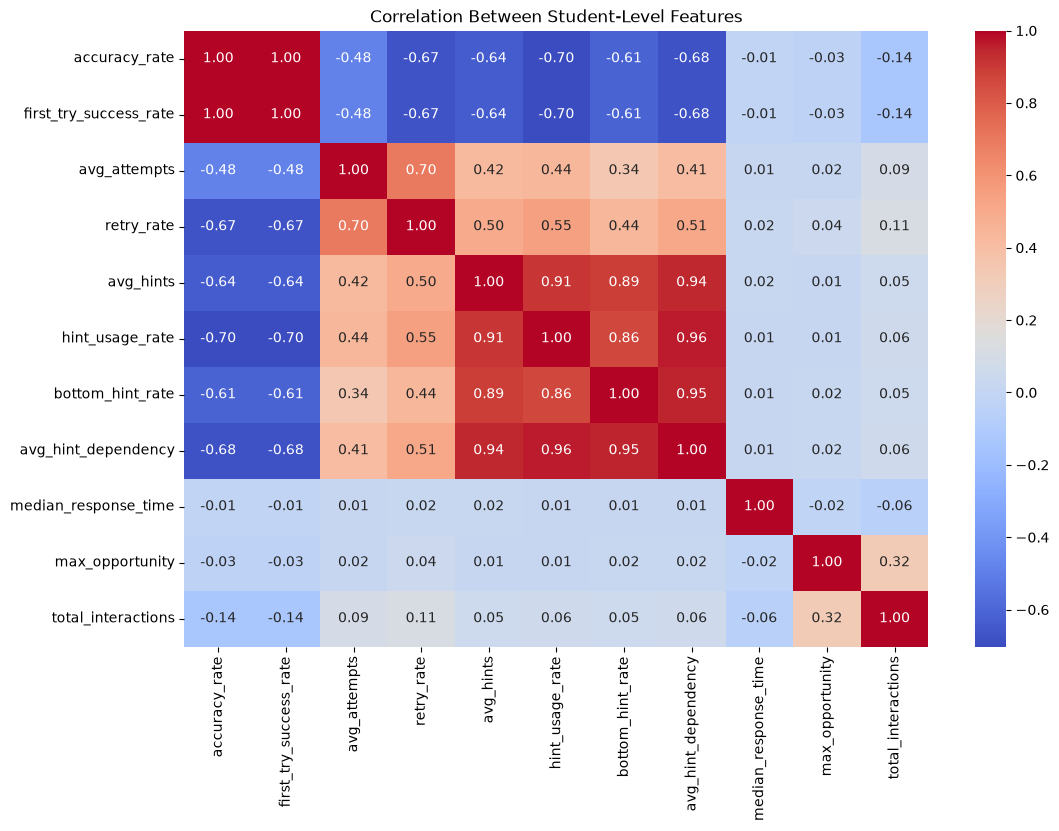

In [59]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    student_skill_df.drop(columns=['user_id', 'skill_id_clean']).corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Student-Level Features')
plt.show()

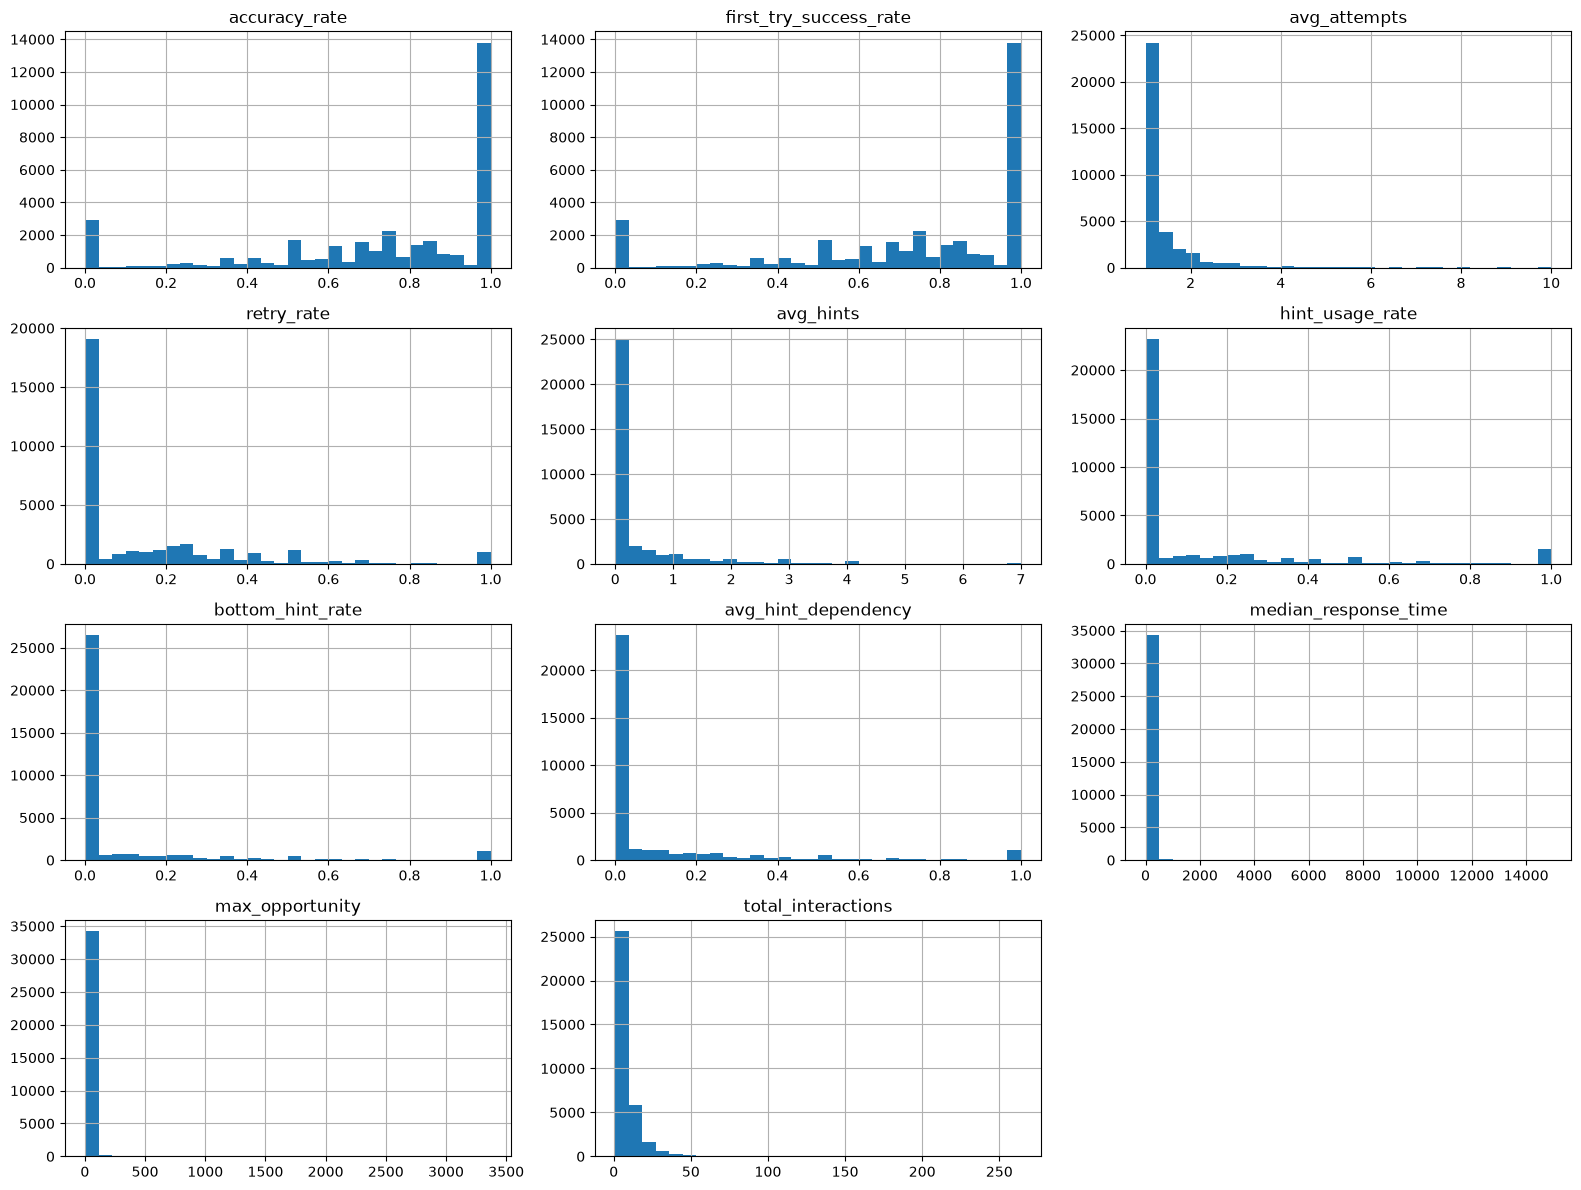

In [60]:
features = [
    'accuracy_rate',
    'first_try_success_rate',
    'avg_attempts',
    'retry_rate',
    'avg_hints',
    'hint_usage_rate',
    'bottom_hint_rate',
    'avg_hint_dependency',
    'median_response_time',
    'max_opportunity',
    'total_interactions',
    
]

student_skill_df[features].hist(
    figsize=(16, 12),
    bins=30
)

plt.tight_layout()
plt.show()

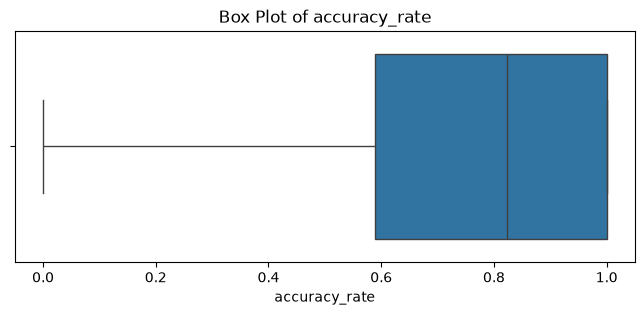

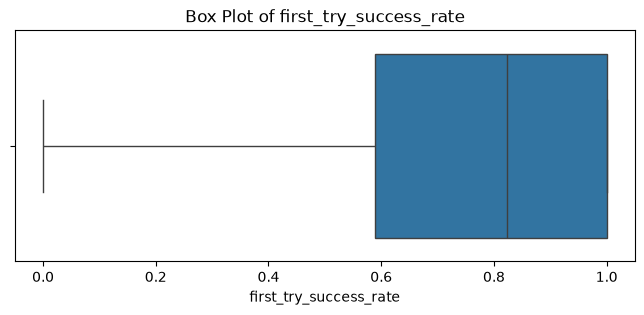

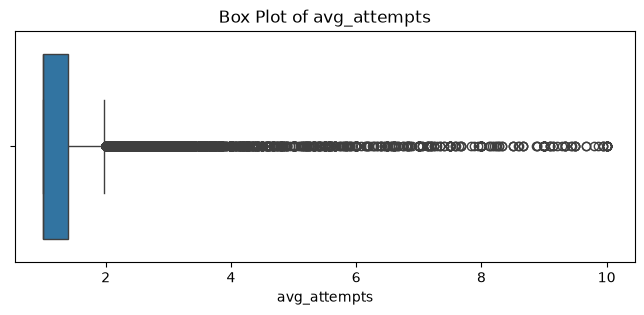

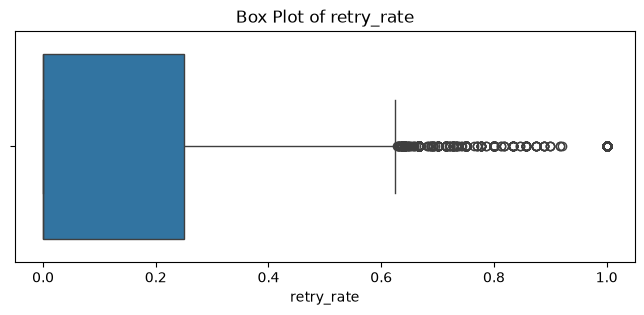

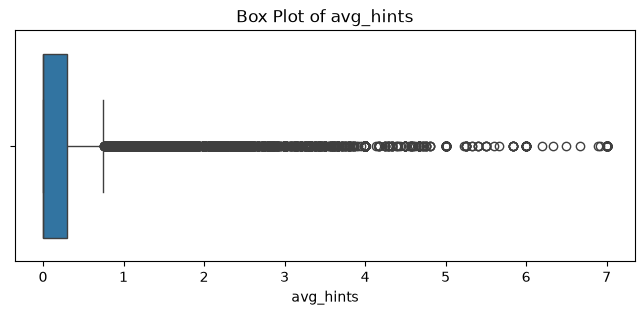

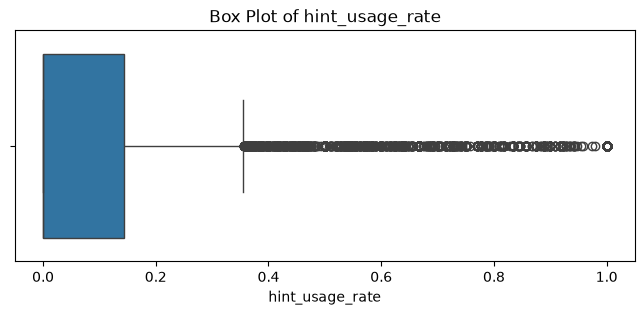

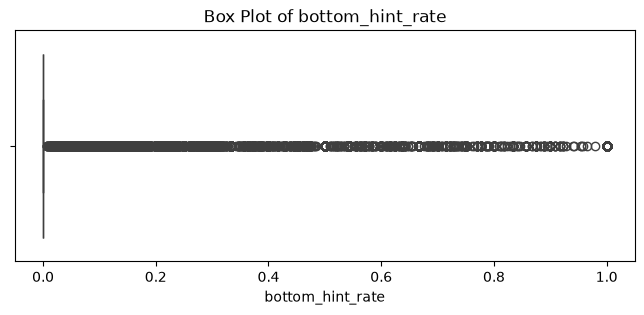

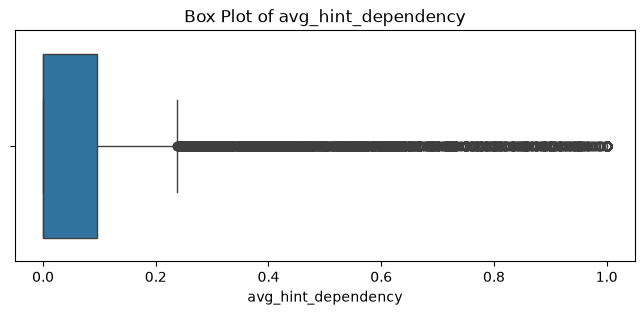

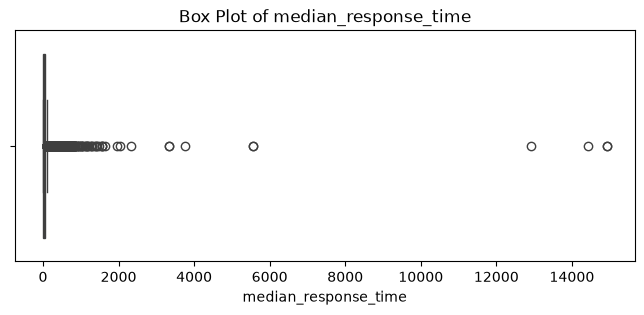

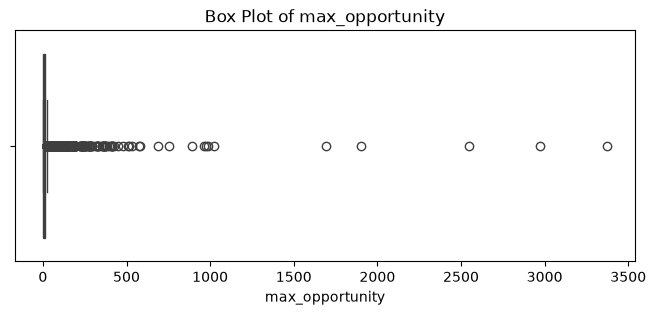

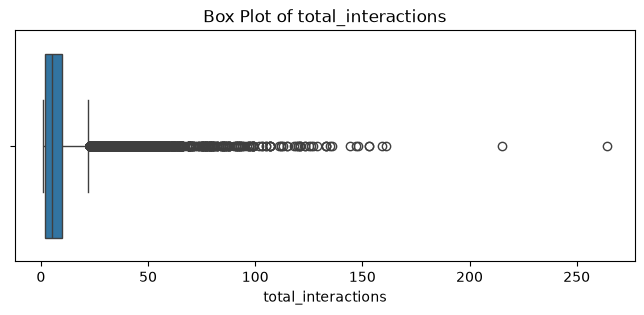

In [61]:
for col in features:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=student_skill_df[col]
    )

    plt.title(f'Box Plot of {col}')
    plt.show()

In [62]:
for col in features:
    Q1 = student_skill_df[col].quantile(0.25)
    Q3 = student_skill_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = student_skill_df[
        (student_skill_df[col] < lower) |
        (student_skill_df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

accuracy_rate: 0 outliers
first_try_success_rate: 0 outliers
avg_attempts: 4234 outliers
retry_rate: 1734 outliers
avg_hints: 5408 outliers
hint_usage_rate: 4431 outliers
bottom_hint_rate: 8115 outliers
avg_hint_dependency: 5361 outliers
median_response_time: 2932 outliers
max_opportunity: 2498 outliers
total_interactions: 2076 outliers


# Insights

* Student-skill profiles show meaningful differences in accuracy, attempts, hint dependency, response time, providing useful behavioral signals for clustering.

* Several behavioral features are **highly skewed and contain extreme values**, so transformation and scaling are necessary before clustering.

* Some engineered features are **strongly correlated**, such as `accuracy_rate` and `first_try_success_rate`. Redundant features should therefore be removed to avoid giving the same behavior excessive influence during clustering.

* Hint-related features also capture similar information, so `avg_hint_dependency` can be used as a more compact representation of students' reliance on hints.

* The EDA suggests that student performance cannot be explained by accuracy alone; combining **performance, effort, hint usage, response time, and practice behavior** provides a more complete representation of learning behavior.


# Preprocessing

In [63]:
import myutils
pd.set_option('display.max_colwidth', None)
x, skew_table = myutils.skew_transform(student_skill_df)
skew_table

,Feature,Original Skewness,Transformations,Final Skewness,Iterations,Status
0,skill_id_clean,0.156,None,0.156,0,Acceptable
1,accuracy_rate,-1.136,Box-Cox,-0.421,1,Acceptable
2,first_try_success_rate,-1.136,Box-Cox,-0.421,1,Acceptable
3,avg_attempts,4.695,Box-Cox -> Square Root,0.393,2,Acceptable
4,retry_rate,1.926,Yeo-Johnson -> Square Root,0.328,2,Acceptable
5,avg_hints,3.368,Box-Cox -> Yeo-Johnson -> Box-Cox -> Yeo-Johnson -> Box-Cox,0.724,5,Still skewed
6,hint_usage_rate,2.324,Yeo-Johnson -> Box-Cox -> Box-Cox -> Yeo-Johnson -> Yeo-Johnson,0.723,5,Still skewed
7,bottom_hint_rate,3.026,Yeo-Johnson -> Yeo-Johnson -> Box-Cox -> Box-Cox -> Yeo-Johnson,1.246,5,Still skewed
8,avg_hint_dependency,2.637,Yeo-Johnson -> Yeo-Johnson -> Box-Cox -> Yeo-Johnson -> Yeo-Johnson,0.724,5,Still skewed
9,median_response_time,64.116,Yeo-Johnson,-0.002,1,Acceptable


In [64]:
from sklearn.base import BaseEstimator, TransformerMixin


class PositiveShifter(BaseEstimator, TransformerMixin):
    """
    Shifts each column so all values become strictly positive,
    which Box-Cox requires. The shift is learned from the
    training data (fit) and reused unchanged on any other data
    (transform) -- no leakage, no re-computing per call.
    """
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        col_min = X.min(axis=0)
        self.shift_ = np.where(col_min <= 0, np.abs(col_min) + 1, 0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return X + self.shift_

In [65]:
student_skill_df.describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
count,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000,34438.000000
mean,83327.158052,42.246094,0.734636,0.734636,1.375079,0.151035,0.374493,0.126567,0.086491,0.106391,44.197039,10.519804,7.717608
std,7311.575725,24.643038,0.310726,0.310726,0.848912,0.233072,0.855312,0.252145,0.217181,0.227986,177.106582,39.436397,10.453220
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.057000,1.000000,1.000000
25%,78968.000000,22.000000,0.588235,0.588235,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.789875,2.000000,2.000000
50%,80354.000000,40.000000,0.823529,0.823529,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.019500,5.000000,5.000000
75%,88095.000000,63.000000,1.000000,1.000000,1.400000,0.250000,0.302273,0.142857,0.000000,0.095238,45.913000,11.000000,10.000000
max,96299.000000,101.000000,1.000000,1.000000,10.000000,1.000000,7.000000,1.000000,1.000000,1.000000,14920.385000,3371.000000,264.000000


In [66]:
student_skill_df.columns

Index(['user_id', 'skill_id_clean', 'accuracy_rate', 'first_try_success_rate',
       'avg_attempts', 'retry_rate', 'avg_hints', 'hint_usage_rate',
       'bottom_hint_rate', 'avg_hint_dependency', 'median_response_time',
       'max_opportunity', 'total_interactions'],
      dtype='str')

In [67]:
num_box_cox = [
    "accuracy_rate",
    "median_response_time",
    "max_opportunity",
    "total_interactions"
]

num_yeojohnson_cols = [
    "avg_attempts",
    "avg_hint_dependency",
]

num_yeojohnson_sqaureroot_cols = [
    "retry_rate"
]

In [77]:
num_box_cox_pipeline = Pipeline([
    ("shift", PositiveShifter()),
    ("transformer", PowerTransformer(method="box-cox", standardize=False)),
    ("scaler", StandardScaler())
])

num_yeojohnson_pipeline = Pipeline([
    ("transformer", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", RobustScaler())
])

num_yeojohnson_sqrt_pipeline = Pipeline([
    ("transformer", PowerTransformer(method="yeo-johnson", standardize= False)),
    ("transformer2", FunctionTransformer(np.sqrt)),
    ("scaler", RobustScaler())
])

In [78]:
preprocessor = ColumnTransformer([
    ("box-cox", num_box_cox_pipeline, num_box_cox),
    ("jeo", num_yeojohnson_pipeline, num_yeojohnson_cols),
    ("jeo-sqrt", num_yeojohnson_sqrt_pipeline, num_yeojohnson_sqaureroot_cols),
    
], remainder="drop")

In [79]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', KMeans(
        n_clusters=3,
        n_init=10,
        init = 'random',
    ))
])


In [80]:
student_skill_df[
    (student_skill_df['accuracy_rate']==0)
]

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster
1,14,10.0,0.0,0.0,1.0,0.0,2.5,1.0,1.0,1.000000,6.3310,4,4,1
11,53167,9.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.000000,93.5520,1,1,2
29,53167,37.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,24.7230,3,3,3
35,53167,43.0,0.0,0.0,5.0,1.0,3.0,1.0,1.0,1.000000,176.0880,1,1,2
41,53167,52.0,0.0,0.0,4.0,1.0,1.0,1.0,0.0,0.333333,21.8950,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34433,96295,11.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.000000,49.5140,13,1,2
34604,96298,2.0,0.0,0.0,4.0,1.0,3.0,1.0,1.0,1.000000,301.2995,2,2,2
34611,96298,13.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,30.5990,1,1,0
34679,96299,73.0,0.0,0.0,2.2,0.8,1.2,0.6,0.6,0.600000,116.0500,5,5,2


# Modelling Approach


The project will use **unsupervised clustering models** to identify groups of similar student-skill performance and learning behavior profiles.

* **K-Means Clustering:** The primary model. The optimal number of clusters will be evaluated using the **Elbow Method** and **Silhouette Score**.
* **Hierarchical Clustering:** A comparison model to examine the hierarchical structure and similarity between student performance profiles.
* **DBSCAN:** An alternative density-based model that can identify dense groups as well as unusual observations or noise.

In [81]:
features = [
    'accuracy_rate',          # drop first_try_success_rate (r=1 duplicate)
    'avg_attempts',           # keep — intensity of struggle
    'retry_rate',             # keep — breadth/frequency of struggle
    'avg_hint_dependency',    # replaces hint_usage_rate + avg_hints + bottom_hint_rate (r≥0.85 redundant)
    'median_response_time',
    'max_opportunity',
    'total_interactions'
]

X = student_skill_df[features]

In [82]:
X.isnull().sum()

accuracy_rate           0
avg_attempts            0
retry_rate              0
avg_hint_dependency     0
median_response_time    0
max_opportunity         0
total_interactions      0
dtype: int64

## 1-K-means

In [83]:
X_processed = full_pipeline.named_steps['preprocessor'].fit_transform(X)

In [84]:
from sklearn.metrics import silhouette_score

kmeans = KMeans(
    n_clusters=4,
    n_init= 10,
    init = 'k-means++',
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_processed)

# Add cluster labels to dataframe
student_skill_df['kmeans_cluster'] = kmeans_labels
student_skill_df[['kmeans_cluster']].value_counts()

kmeans_cluster
3                 10206
0                  9703
1                  9629
2                  4900
Name: count, dtype: int64

In [85]:
kmeans_silhouette = silhouette_score(
    X_processed,
    kmeans_labels
)

print("K-Means Silhouette Score:", kmeans_silhouette)

K-Means Silhouette Score: 0.2881288654388855


## 2- PCA

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_processed)

In [87]:
X_pca.shape

(34438, 3)

In [88]:
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum())

[0.49787111 0.23228947 0.16840429]
0.8985648784243324


In [89]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
)

clusters = kmeans.fit_predict(X_pca)

student_skill_df['kmeans_cluster_with_PCA'] = clusters
student_skill_df[['kmeans_cluster_with_PCA']].value_counts()

kmeans_cluster_with_PCA
0                          20057
1                          14381
Name: count, dtype: int64

In [90]:
from sklearn.metrics import davies_bouldin_score

silhouette = silhouette_score(X_pca, clusters)
db_score = davies_bouldin_score(X_pca, clusters)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", db_score)

Silhouette Score: 0.36628130542902754
Davies-Bouldin Score: 1.0884539948966563


## 3-GMM

In [103]:
# Initialize and fit GMM
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_processed)

student_skill_df['gmm_cluster'] = gmm_labels
student_skill_df[['gmm_cluster']].value_counts()

gmm_cluster
1              17880
2              13813
0               2745
Name: count, dtype: int64

In [99]:
silhouette = silhouette_score(X_processed, gmm_labels)
db_score = davies_bouldin_score(X_processed, gmm_labels)

print("Silhouette Score:", silhouette)
print("Davies-Bouldin Score:", db_score)

Silhouette Score: 0.18834491332817588
Davies-Bouldin Score: 3.0958837994423


In [104]:
student_skill_df.groupby('gmm_cluster')[features].mean()

,accuracy_rate,avg_attempts,retry_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
gmm_cluster,,,,,,,
0,0.553973,1.619361,0.267171,0.226103,42.403948,41.473953,19.365027
1,0.903424,1.000000,0.000000,0.000000,50.454703,5.907494,3.932159
2,0.552054,1.812048,0.323460,0.220318,36.453246,10.338739,10.302975


# Examine the result

## 1- k-means

In [84]:
student_skill_df[
    student_skill_df['kmeans_cluster'].isin([0])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.000000,9703.0,9703.000000,9703.000000
mean,83756.149438,43.489333,0.558064,0.558064,1.745025,0.286000,0.754924,0.253290,0.180819,0.219036,26.069931,22.132330,16.190869,0.0,0.189941,0.502525
std,7225.862730,25.686558,0.226307,0.226307,0.908140,0.173885,0.913514,0.261911,0.249227,0.250679,23.239562,67.670689,15.251781,0.0,0.613943,1.077672
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.082500,3.000000,1.000000,0.0,0.000000,0.000000
25%,78985.000000,25.000000,0.437060,0.437060,1.250000,0.166667,0.117647,0.062500,0.000000,0.036039,11.309500,8.000000,7.000000,0.0,0.000000,0.000000
50%,83169.000000,40.000000,0.607143,0.607143,1.500000,0.250000,0.444444,0.166667,0.090909,0.133333,19.757000,13.000000,12.000000,0.0,0.000000,0.000000
75%,88209.000000,64.000000,0.727273,0.727273,1.888889,0.398413,1.000000,0.363636,0.250000,0.300000,33.081500,22.000000,19.000000,0.0,0.000000,0.000000
max,96299.000000,101.000000,0.956522,0.956522,9.941176,1.000000,7.000000,1.000000,1.000000,1.000000,310.346500,3371.000000,264.000000,0.0,3.000000,3.000000


In [85]:
student_skill_df[
    (student_skill_df['kmeans_cluster'].isin([0]))&
    (student_skill_df['accuracy_rate'] == 0)
]

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
1,14,10.0,0.0,0.0,1.000000,0.000000,2.500000,1.000000,1.000000,1.000000,6.3310,4,4,0,2,2
1292,70746,68.0,0.0,0.0,1.400000,0.400000,1.800000,0.600000,0.400000,0.550000,3.6410,5,5,0,0,0
1467,70759,68.0,0.0,0.0,1.571429,0.428571,2.285714,0.857143,0.285714,0.690476,19.3990,8,7,0,0,0
1831,71225,10.0,0.0,0.0,1.000000,0.000000,1.200000,1.000000,0.200000,0.533333,6.8910,7,5,0,0,2
1833,71225,42.0,0.0,0.0,1.000000,0.000000,1.000000,0.750000,0.500000,0.625000,2.6485,4,4,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31434,96244,18.0,0.0,0.0,2.800000,1.000000,0.800000,0.400000,0.200000,0.333333,10.5100,5,5,0,0,0
31826,96250,66.0,0.0,0.0,2.000000,0.500000,5.833333,0.833333,0.833333,0.833333,19.9600,6,6,0,2,0
32294,96258,66.0,0.0,0.0,4.166667,0.833333,7.000000,1.000000,1.000000,1.000000,32.5985,6,6,0,2,0
32370,96259,87.0,0.0,0.0,1.333333,0.333333,3.333333,1.000000,1.000000,1.000000,4.7160,4,3,0,2,0


In [86]:
student_skill_df[
    (student_skill_df['avg_attempts'] == 1)&
    (student_skill_df['avg_hint_dependency']==0)&
    (student_skill_df['accuracy_rate']==0)

]

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
29,53167,37.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,24.7230,3,3,2,2,2
153,69931,62.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.1260,1,1,2,2,2
175,70657,7.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,43.5465,2,2,2,2,2
214,70677,43.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,224.5950,1,1,2,2,2
225,70679,6.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,76.4380,4,4,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33267,96275,46.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,23.0380,1,1,2,2,2
33272,96275,62.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,25.7920,2,1,2,2,2
33313,96276,22.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,63.4450,1,1,2,2,2
34337,96293,46.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,142.6540,1,1,2,2,2


In [87]:
student_skill_df[
    student_skill_df['kmeans_cluster'].isin([1])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,9629.000000,9629.000000,9629.0,9629.0,9629.0,9629.0,9629.0,9629.0,9629.0,9629.0,9629.000000,9629.000000,9629.000000,9629.0,9629.00000,9629.0
mean,83458.751480,43.424447,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,64.381347,1.706719,1.457680,1.0,1.02804,1.0
std,7492.614496,24.756887,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,226.495164,1.278671,0.653996,0.0,0.23516,0.0
min,51950.000000,1.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.626000,1.000000,1.000000,1.0,1.00000,1.0
25%,78926.000000,21.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,16.135000,1.000000,1.000000,1.0,1.00000,1.0
50%,80126.000000,41.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,32.099000,1.000000,1.000000,1.0,1.00000,1.0
75%,88824.000000,64.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,66.452000,2.000000,2.000000,1.0,1.00000,1.0
max,96299.000000,99.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,14422.416000,21.000000,5.000000,1.0,3.00000,1.0


In [88]:
student_skill_df[
    (student_skill_df['kmeans_cluster'].isin([3]))&
    (student_skill_df['accuracy_rate'] == 0)
]

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
20649,83925,41.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.9330,4,4,3,0,2
23047,85262,43.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,7.0155,10,2,3,0,2
26189,88143,62.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.3200,7,3,3,0,2
26968,89051,41.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,8.0460,7,4,3,0,2


In [89]:
student_skill_df[
    student_skill_df['kmeans_cluster'].isin([2])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.000000,4900.0,4900.000000,4900.000000
mean,83323.474082,43.354898,0.271323,0.271323,2.033157,0.409491,1.090968,0.363281,0.243432,0.300410,78.844365,2.970204,2.700204,2.0,1.997347,1.235102
std,6272.326204,25.738791,0.287000,0.287000,1.471822,0.370682,1.460716,0.399713,0.368724,0.365180,337.270135,2.067431,1.564729,0.0,0.084482,1.241518
min,53167.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.057000,1.000000,1.000000,2.0,0.000000,0.000000
25%,79017.000000,20.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,24.584625,1.000000,1.000000,2.0,2.000000,0.000000
50%,82679.500000,43.000000,0.200000,0.200000,1.500000,0.333333,0.500000,0.250000,0.000000,0.133333,45.558500,3.000000,2.000000,2.0,2.000000,2.000000
75%,87413.250000,65.000000,0.500000,0.500000,2.250000,0.666667,2.000000,0.666667,0.500000,0.500000,83.089750,4.000000,4.000000,2.0,2.000000,2.000000
max,96299.000000,101.000000,0.833333,0.833333,10.000000,1.000000,7.000000,1.000000,1.000000,1.000000,14920.385000,48.000000,9.000000,2.0,3.000000,3.000000


In [90]:
student_skill_df[
    student_skill_df['kmeans_cluster'].isin([3])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.000000,10206.0,10206.000000,10206.000000
mean,82796.924358,39.420047,0.874586,0.874586,1.061288,0.041130,0.022146,0.011853,0.003064,0.006524,25.753057,11.419067,7.976876,3.0,2.847051,1.664413
std,7644.305640,22.679524,0.137242,0.137242,0.196392,0.074877,0.102036,0.046667,0.023301,0.029045,26.722942,25.715225,5.348754,0.0,0.644446,0.880493
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.253000,2.000000,1.000000,3.0,0.000000,0.000000
25%,78905.000000,25.000000,0.800000,0.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.427875,5.000000,5.000000,3.0,3.000000,1.000000
50%,79675.000000,38.000000,0.888889,0.888889,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.824000,8.000000,6.000000,3.0,3.000000,2.000000
75%,87518.750000,60.000000,1.000000,1.000000,1.076923,0.066667,0.000000,0.000000,0.000000,0.000000,31.980750,12.000000,10.000000,3.0,3.000000,2.000000
max,96299.000000,101.000000,1.000000,1.000000,8.333333,0.333333,1.333333,0.400000,0.333333,0.333333,666.097000,1690.000000,60.000000,3.0,3.000000,3.000000


In [109]:
cluster_profiles = student_skill_df.groupby('kmeans_cluster')[features].mean()
cluster_profiles

,accuracy_rate,avg_attempts,retry_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
kmeans_cluster,,,,,,,
0,0.558064,1.745025,0.286000,0.219036,26.069931,22.132330,16.190869
1,1.000000,1.000000,0.000000,0.000000,64.381347,1.706719,1.457680
2,0.271323,2.033157,0.409491,0.300410,78.844365,2.970204,2.700204
3,0.874586,1.061288,0.041130,0.006524,25.753057,11.419067,7.976876


In [92]:
student_skill_df[['kmeans_cluster']].value_counts()

kmeans_cluster
3                 10206
0                  9703
1                  9629
2                  4900
Name: count, dtype: int64

## 2-K-means with PCA

In [93]:
student_skill_df[
    student_skill_df['kmeans_cluster_with_PCA'].isin([0])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.000000,9329.0,9329.000000
mean,83696.266802,43.085754,0.560326,0.560326,1.693991,0.269854,0.694307,0.233574,0.168239,0.202596,25.121751,23.489763,17.159503,0.158002,0.0,0.614750
std,7194.318489,25.542169,0.224067,0.224067,0.878066,0.176392,0.898739,0.262386,0.245839,0.249908,22.180513,69.201186,15.340191,0.668860,0.0,1.146785
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.082500,3.000000,1.000000,0.000000,0.0,0.000000
25%,78982.000000,25.000000,0.444444,0.444444,1.222222,0.142857,0.040816,0.027027,0.000000,0.011905,10.844000,9.000000,8.000000,0.000000,0.0,0.000000
50%,82262.000000,40.000000,0.615385,0.615385,1.444444,0.250000,0.375000,0.142857,0.071429,0.111111,19.093000,14.000000,13.000000,0.000000,0.0,0.000000
75%,88173.000000,64.000000,0.727273,0.727273,1.833333,0.375000,0.986667,0.333333,0.222222,0.281250,31.865500,23.000000,20.000000,0.000000,0.0,0.000000
max,96299.000000,101.000000,0.956522,0.956522,9.941176,1.000000,7.000000,1.000000,1.000000,1.000000,261.182500,3371.000000,264.000000,3.000000,0.0,3.000000


In [94]:
student_skill_df[
    student_skill_df['kmeans_cluster_with_PCA'].isin([1])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,9494.000000,9494.000000,9494.0,9494.0,9494.0,9494.0,9494.0,9494.0,9494.0,9494.0,9494.000000,9494.000000,9494.000000,9494.0,9494.0,9494.0
mean,83467.757215,43.418475,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,64.946298,1.679903,1.437224,1.0,1.0,1.0
std,7479.475113,24.761295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,228.034219,1.255189,0.630862,0.0,0.0,0.0
min,51950.000000,1.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.626000,1.000000,1.000000,1.0,1.0,1.0
25%,78928.000000,21.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,16.211750,1.000000,1.000000,1.0,1.0,1.0
50%,80127.500000,41.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,32.552000,1.000000,1.000000,1.0,1.0,1.0
75%,88823.750000,64.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,66.914000,2.000000,2.000000,1.0,1.0,1.0
max,96299.000000,99.000000,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,14422.416000,21.000000,5.000000,1.0,1.0,1.0


In [95]:
student_skill_df[
    student_skill_df['kmeans_cluster_with_PCA'].isin([2])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.000000,5753.0,5753.000000
mean,83430.721884,43.584391,0.314828,0.314828,2.017248,0.397896,1.074760,0.357835,0.238912,0.296228,73.204113,3.418217,3.108465,1.753346,2.0,1.108465
std,6497.041343,25.795175,0.297004,0.297004,1.423815,0.350566,1.397538,0.380061,0.353780,0.348940,311.829898,2.796461,1.818824,0.697327,0.0,1.238319
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.057000,1.000000,1.000000,0.000000,2.0,0.000000
25%,79019.000000,22.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.547000,2.000000,2.000000,2.000000,2.0,0.000000
50%,83169.000000,43.000000,0.333333,0.333333,1.500000,0.333333,0.500000,0.250000,0.000000,0.166667,42.355500,3.000000,3.000000,2.000000,2.0,0.000000
75%,87521.000000,65.000000,0.600000,0.600000,2.250000,0.600000,1.666667,0.600000,0.400000,0.500000,76.438000,5.000000,4.000000,2.000000,2.0,2.000000
max,96299.000000,101.000000,0.857143,0.857143,10.000000,1.000000,7.000000,1.000000,1.000000,1.000000,14920.385000,94.000000,12.000000,3.000000,2.0,3.000000


In [96]:
student_skill_df[
    student_skill_df['kmeans_cluster_with_PCA'].isin([3])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.000000,9862.0,9862.000000
mean,82782.231393,39.542486,0.888960,0.888960,1.059875,0.040029,0.023982,0.012278,0.003510,0.007065,25.345102,10.903569,7.520787,2.939769,3.0,1.616102
std,7668.331742,22.691696,0.122687,0.122687,0.182310,0.073440,0.103421,0.046065,0.024061,0.029519,26.289360,25.124619,4.683376,0.386128,0.0,0.879320
min,14.000000,1.000000,0.250000,0.250000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.253000,2.000000,1.000000,0.000000,3.0,0.000000
25%,78904.000000,26.000000,0.800000,0.800000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.383500,5.000000,4.000000,3.000000,3.0,1.000000
50%,79673.500000,38.000000,0.909091,0.909091,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.526500,7.000000,6.000000,3.000000,3.0,1.000000
75%,87512.750000,60.000000,1.000000,1.000000,1.071429,0.066667,0.000000,0.000000,0.000000,0.000000,31.397500,11.000000,10.000000,3.000000,3.0,2.000000
max,96299.000000,101.000000,1.000000,1.000000,8.333333,0.333333,1.333333,0.400000,0.333333,0.333333,666.097000,1690.000000,58.000000,3.000000,3.0,3.000000


In [97]:
cluster_profiles_pca = student_skill_df.groupby('kmeans_cluster')[features].mean()
cluster_profiles_pca

,accuracy_rate,avg_attempts,retry_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
kmeans_cluster,,,,,,,
0,0.558064,1.745025,0.286000,0.219036,26.069931,22.132330,16.190869
1,1.000000,1.000000,0.000000,0.000000,64.381347,1.706719,1.457680
2,0.271323,2.033157,0.409491,0.300410,78.844365,2.970204,2.700204
3,0.874586,1.061288,0.041130,0.006524,25.753057,11.419067,7.976876


In [98]:
student_skill_df.groupby('kmeans_cluster_with_PCA')[features].mean()

,accuracy_rate,avg_attempts,retry_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
kmeans_cluster_with_PCA,,,,,,,
0,0.560326,1.693991,0.269854,0.202596,25.121751,23.489763,17.159503
1,1.000000,1.000000,0.000000,0.000000,64.946298,1.679903,1.437224
2,0.314828,2.017248,0.397896,0.296228,73.204113,3.418217,3.108465
3,0.888960,1.059875,0.040029,0.007065,25.345102,10.903569,7.520787


## 3-GMM

In [93]:
student_skill_df[
    student_skill_df['gmm_cluster'].isin([0])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.000000,16558.0
mean,83667.421911,43.445827,0.552372,0.552372,1.780104,0.314128,0.778886,0.263240,0.179887,0.221277,37.439759,15.500362,11.805290,1.045899,0.030861,0.0
std,7143.489508,25.710571,0.282548,0.282548,1.087615,0.248497,1.098444,0.310249,0.285136,0.287551,180.259745,52.806789,13.193191,1.257390,0.172947,0.0
min,14.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.057000,1.000000,1.000000,0.000000,0.000000,0.0
25%,78986.000000,25.000000,0.400000,0.400000,1.200000,0.142857,0.000000,0.000000,0.000000,0.000000,12.468625,5.000000,4.000000,0.000000,0.000000,0.0
50%,82284.000000,40.000000,0.636364,0.636364,1.428571,0.250000,0.333333,0.159091,0.000000,0.107143,22.672000,9.000000,8.000000,0.000000,0.000000,0.0
75%,88144.000000,64.000000,0.756098,0.756098,2.000000,0.411765,1.000000,0.400000,0.250000,0.320000,40.731750,16.000000,14.000000,2.000000,0.000000,0.0
max,96299.000000,101.000000,0.975000,0.975000,10.000000,1.000000,7.000000,1.000000,1.000000,1.000000,14920.385000,3371.000000,264.000000,3.000000,1.000000,0.0


In [94]:
student_skill_df[
    student_skill_df['gmm_cluster'].isin([1])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.0,17880.0,17880.0,17880.0,17880.0,17880.0,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000,17880.0
mean,83012.052405,41.135067,0.903424,0.903424,1.0,0.0,0.0,0.0,0.0,0.0,50.454703,5.907494,3.932159,1.830481,0.775727,1.0
std,7450.211356,23.557723,0.229740,0.229740,0.0,0.0,0.0,0.0,0.0,0.0,173.906681,19.207687,4.412613,0.971752,0.417114,0.0
min,14.000000,1.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,1.253000,1.000000,1.000000,0.000000,0.000000,1.0
25%,78911.000000,21.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,13.109500,1.000000,1.000000,1.000000,1.000000,1.0
50%,79764.000000,40.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,25.455000,2.000000,2.000000,1.000000,1.000000,1.0
75%,87999.000000,62.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,52.008000,6.000000,5.000000,3.000000,1.000000,1.0
max,96299.000000,101.000000,1.000000,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,14422.416000,1690.000000,53.000000,3.000000,1.000000,1.0


In [95]:
student_skill_df[
    student_skill_df['gmm_cluster'].isin([2])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [96]:
student_skill_df[
    student_skill_df['gmm_cluster'].isin([3])
].describe()

,user_id,skill_id_clean,accuracy_rate,first_try_success_rate,avg_attempts,retry_rate,avg_hints,hint_usage_rate,bottom_hint_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions,kmeans_cluster,kmeans_cluster_with_PCA,gmm_cluster
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
student_skill_df.groupby('gmm_cluster')[features].mean()

,accuracy_rate,avg_attempts,retry_rate,avg_hint_dependency,median_response_time,max_opportunity,total_interactions
gmm_cluster,,,,,,,
0,0.552372,1.780104,0.314128,0.221277,37.439759,15.500362,11.805290
1,0.903424,1.000000,0.000000,0.000000,50.454703,5.907494,3.932159


# Improved Version

## 1- Improve K-means version

In [104]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.cluster import KMeans

def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    if len(set(labels)) < 2:
        return -1
    return silhouette_score(X, labels)

def davies_bouldin_scorer(estimator, X):
    # GridSearchCV always maximizes the score, but lower Davies-Bouldin
    # is better -- so negate it to keep "higher is better" consistent
    labels = estimator.fit_predict(X)
    if len(set(labels)) < 2:
        return -np.inf
    return -davies_bouldin_score(X, labels)

In [105]:
full_data_cv = [(np.arange(len(X_processed)), np.arange(len(X_processed)))]

param_grid = {
    'n_clusters': list(range(2, 5)),
    'init': ['k-means++', 'random'],
    'n_init': [10],
    'max_iter': [300],
    'random_state': [42]
}


kmeans_grid = GridSearchCV(
    estimator=KMeans(random_state=42),
    param_grid=param_grid,
    scoring={
        'silhouette': silhouette_scorer,
        'davies_bouldin': davies_bouldin_scorer,
    },
    cv=full_data_cv,  
    refit='silhouette',   # picks best_estimator_ based on silhouette
    n_jobs=-1,
)

kmeans_grid.fit(X_processed)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KMeans(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'init': ['k-means++', 'random'], 'max_iter': [300], 'n_clusters': [2, 3, ...], 'n_init': [10], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'davies_bouldin': <function dav...001FB7618FA60>, 'silhouette': <function sil...001FB7618E520>}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'silhouette'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22

In [106]:
kmeans_results = pd.DataFrame({
    'n_clusters': kmeans_grid.cv_results_['param_n_clusters'],
    'init': kmeans_grid.cv_results_['param_init'],
    'n_init': kmeans_grid.cv_results_['param_n_init'],
    'max_iter': kmeans_grid.cv_results_['param_max_iter'],

    'silhouette_score': kmeans_grid.cv_results_['mean_test_silhouette'],

    # Convert back to positive because scorer used negative DB score
    'davies_bouldin_score': -kmeans_grid.cv_results_['mean_test_davies_bouldin']
})

kmeans_results

,n_clusters,init,n_init,max_iter,silhouette_score,davies_bouldin_score
0,2,k-means++,10,300,0.332478,1.197629
1,3,k-means++,10,300,0.284203,1.387178
2,4,k-means++,10,300,0.288129,1.282524
3,2,random,10,300,0.332420,1.198502
4,3,random,10,300,0.284725,1.388174
5,4,random,10,300,0.287968,1.282458


In [107]:
print("Best params:", kmeans_grid.best_params_)
print("Best silhouette score:", kmeans_grid.best_score_)

best_kmedoids = kmeans_grid.best_estimator_


Best params: {'init': 'k-means++', 'max_iter': 300, 'n_clusters': 2, 'n_init': 10, 'random_state': 42}
Best silhouette score: 0.3324780278208216


## 2-Improve K-means with PCA version

In [108]:
full_data_cv = [(np.arange(len(X)), np.arange(len(X)))]

param_grid = {
    'n_clusters': list(range(2, 5)),
    'init': ['k-means++', 'random'],
    'n_init': [10],
    'max_iter': [300]
}


kmeans_with_pca_grid = GridSearchCV(
    estimator=KMeans(random_state=42),
    param_grid=param_grid,
    scoring={
        'silhouette': silhouette_scorer,
        'davies_bouldin': davies_bouldin_scorer,
    },
    cv=full_data_cv,  
    refit='silhouette',   # picks best_estimator_ based on silhouette
    n_jobs=-1,
)

kmeans_with_pca_grid.fit(X_pca)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KMeans(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'init': ['k-means++', 'random'], 'max_iter': [300], 'n_clusters': [2, 3, ...], 'n_init': [10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'davies_bouldin': <function dav...001FB7618FA60>, 'silhouette': <function sil...001FB7618E520>}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'silhouette'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv

In [109]:
kmeans_with_pca_results = pd.DataFrame({
    'n_clusters': kmeans_with_pca_grid.cv_results_['param_n_clusters'],
    'init': kmeans_with_pca_grid.cv_results_['param_init'],
    'n_init': kmeans_with_pca_grid.cv_results_['param_n_init'],
    'max_iter': kmeans_with_pca_grid.cv_results_['param_max_iter'],

    'silhouette_score':
        kmeans_with_pca_grid.cv_results_['mean_test_silhouette'],

    'davies_bouldin_score':
        -kmeans_with_pca_grid.cv_results_['mean_test_davies_bouldin']
})

kmeans_with_pca_results

,n_clusters,init,n_init,max_iter,silhouette_score,davies_bouldin_score
0,2,k-means++,10,300,0.366143,1.089374
1,3,k-means++,10,300,0.331320,1.178242
2,4,k-means++,10,300,0.317295,1.112183
3,2,random,10,300,0.366202,1.089058
4,3,random,10,300,0.331570,1.175500
5,4,random,10,300,0.317382,1.112528


## 3-Improve GMM version

In [110]:
from sklearn.mixture import GaussianMixture

full_data_cv = [(np.arange(len(X_processed)), np.arange(len(X_processed)))]

param_grid = {
    'n_components': list(range(2, 5)),     # GMM uses n_components, not n_clusters
    'init_params': ['kmeans', 'random'],   # GMM's init options
    'n_init': [10],
    'max_iter': [300],
}

gmm_grid = GridSearchCV(
    estimator=GaussianMixture(random_state=42),
    param_grid=param_grid,
    scoring={
        'silhouette': silhouette_scorer,
        'davies_bouldin': davies_bouldin_scorer,
    },
    cv=full_data_cv,
    refit='silhouette',
    n_jobs=-1,
)
gmm_grid.fit(X_processed)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GaussianMixtu...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'init_params': ['kmeans', 'random'], 'max_iter': [300], 'n_components': [2, 3, ...], 'n_init': [10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'davies_bouldin': <function dav...001FB7618FA60>, 'silhouette': <function sil...001FB7618E520>}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'silhouette'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchange

In [111]:
gmm_results = pd.DataFrame({
    'n_components': gmm_grid.cv_results_['param_n_components'],
    'init_params': gmm_grid.cv_results_['param_init_params'],
    'n_init': gmm_grid.cv_results_['param_n_init'],
    'max_iter': gmm_grid.cv_results_['param_max_iter'],

    'silhouette_score':
        gmm_grid.cv_results_['mean_test_silhouette'],

    'davies_bouldin_score':
        -gmm_grid.cv_results_['mean_test_davies_bouldin']
})

gmm_results

,n_components,init_params,n_init,max_iter,silhouette_score,davies_bouldin_score
0,2,kmeans,10,300,0.300934,1.351176
1,3,kmeans,10,300,0.209234,3.737715
2,4,kmeans,10,300,0.214720,2.075545
3,2,random,10,300,0.075770,4.144923
4,3,random,10,300,0.184244,3.084949
5,4,random,10,300,0.191039,3.345515


# Conclusion

# Choosing the best improvement version (comparison)

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 1. Normalize the cluster profiles to a 0-1 scale for visual comparison
scaler = MinMaxScaler()
normalized_profiles = pd.DataFrame(
    scaler.fit_transform(cluster_profiles), 
    columns=cluster_profiles.columns, 
    index=cluster_profiles.index
)

# 2. Give temporary names 
persona_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3'    
}
normalized_profiles.index = normalized_profiles.index.map(persona_names)

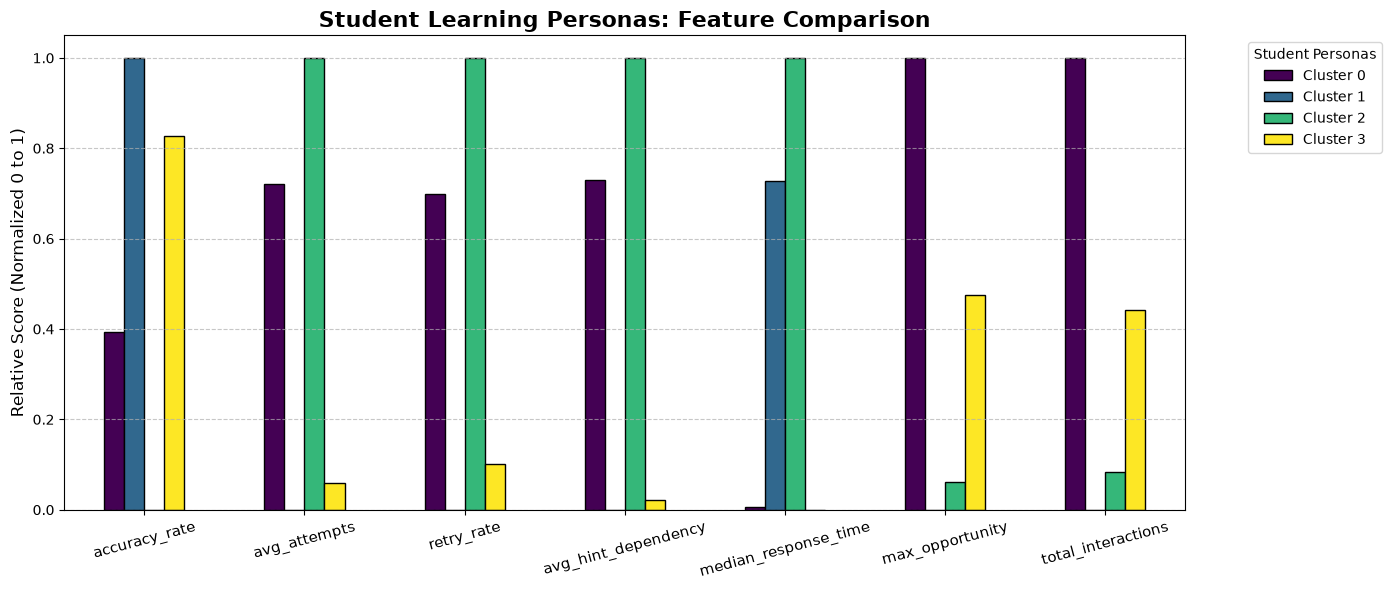

In [111]:
# Create the Grouped Bar Chart
ax = normalized_profiles.T.plot(
    kind='bar', 
    figsize=(14, 6), 
    colormap='viridis', 
    edgecolor='black'
)

plt.title('Student Learning Personas: Feature Comparison', fontsize=16, fontweight='bold')
plt.ylabel('Relative Score (Normalized 0 to 1)', fontsize=12)
plt.xticks(rotation=15, fontsize=11)
plt.legend(title='Student Personas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

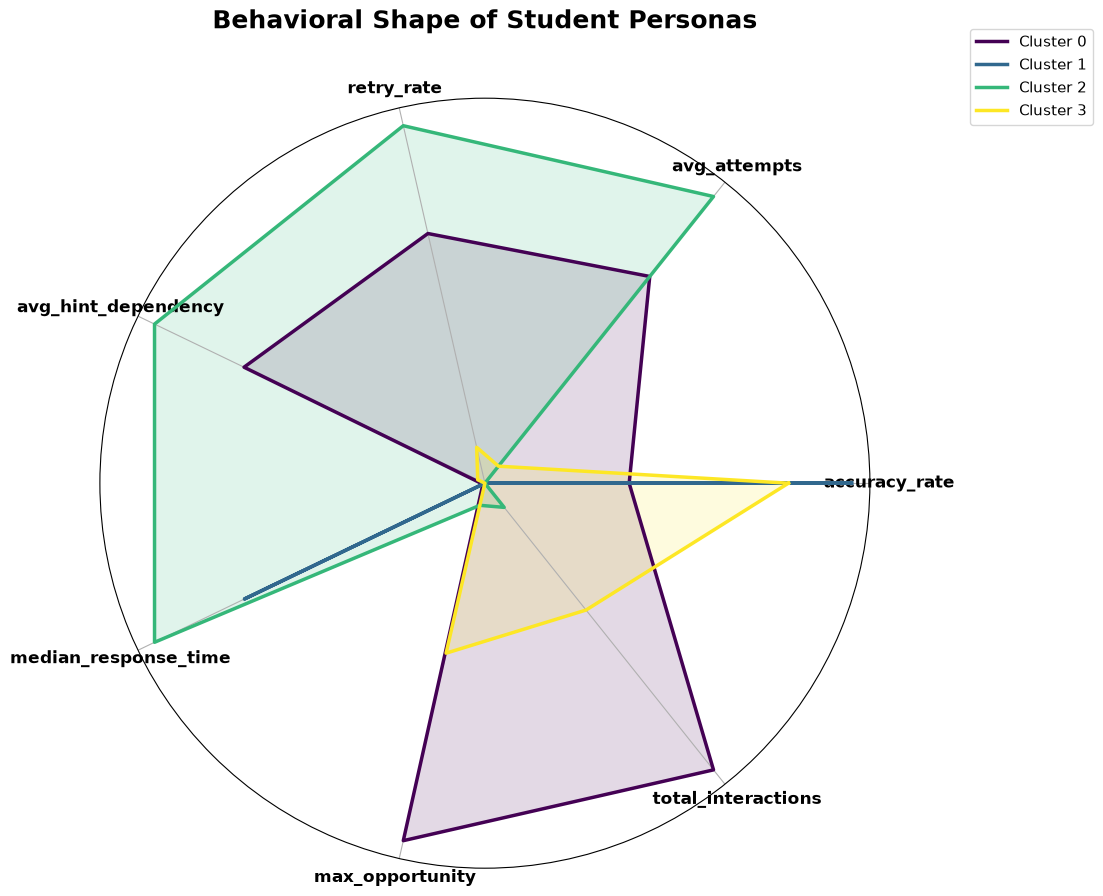

In [113]:
# Setup the radar chart angles and features
features = normalized_profiles.columns.tolist()
num_vars = len(features)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1] # Close the loop

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ['#440154', '#31688e', '#35b779', '#fde725'] # Matching the viridis colormap

# Plot each persona
for i, (persona, row) in enumerate(normalized_profiles.iterrows()):
    values = row.tolist()
    values += values[:1] # Close the loop
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=persona)
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# Format the chart to look professional
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, fontweight='bold')
ax.set_yticks([]) # Hide the concentric circular grid labels to keep it clean

plt.title('Behavioral Shape of Student Personas', size=18, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.show()

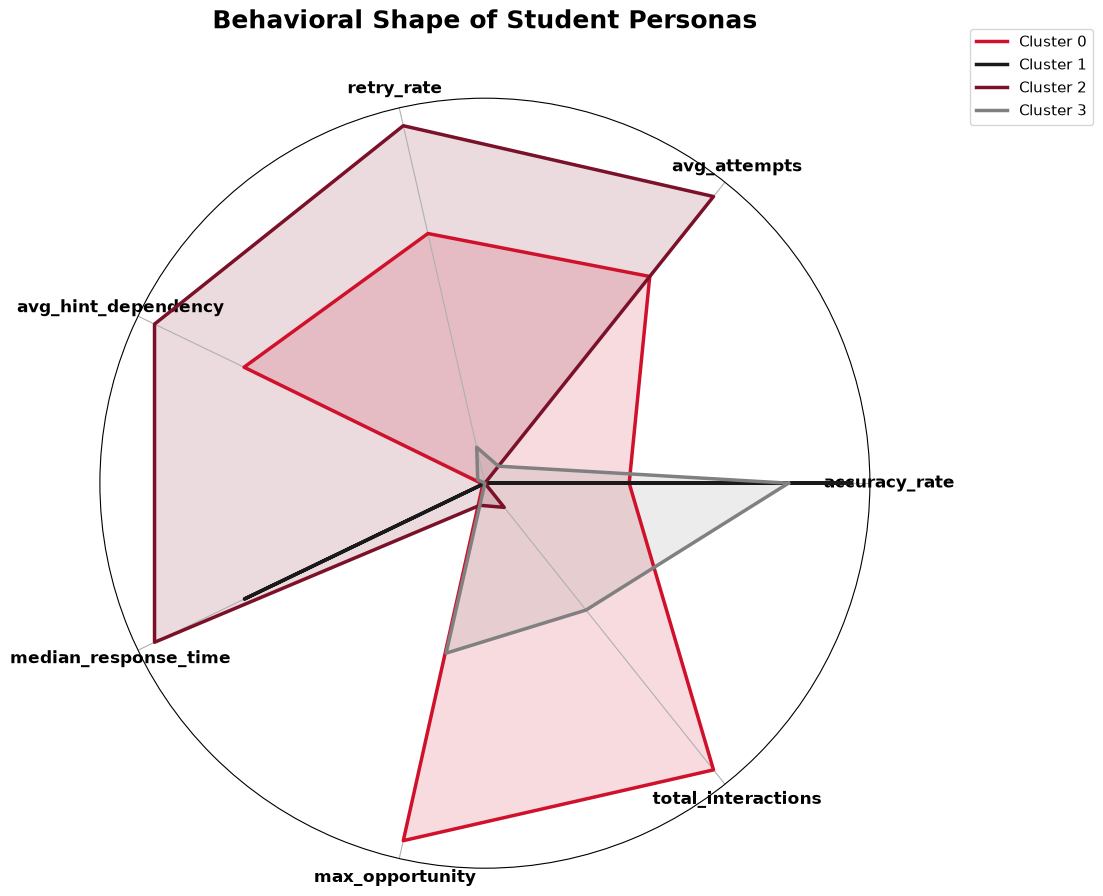

In [114]:
# for prensetation 

# Setup the radar chart angles and features
features = normalized_profiles.columns.tolist()
num_vars = len(features)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]  # Close the loop

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ['#D0112B', '#1A1A1A', '#7A1128', '#808080']  # Active Strivers, Deliberate Masters, Overwhelmed & Struggling, Efficient Practicers

# Plot each persona
for i, (persona, row) in enumerate(normalized_profiles.iterrows()):
    values = row.tolist()
    values += values[:1]  # Close the loop
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=persona)
    ax.fill(angles, values, color=colors[i], alpha=0.15)

# Format the chart to look professional
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, fontweight='bold')
ax.set_yticks([])  # Hide the concentric circular grid labels to keep it clean
plt.title('Behavioral Shape of Student Personas', size=18, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.show()

## Literature Review Summary

I found a solid base of peer-reviewed work directly relevant to this dataset — several studies use ASSISTments specifically, and the broader intelligent tutoring systems (ITS) literature has well-established constructs for exactly the behaviors your features capture (hint use, retries, response time, practice volume). Two threads are most useful here:

- **Help-seeking and hint use**: research on ASSISTments found that when on-demand hints were available, students who requested more hints tended to perform better on algebra assignments — but this is not universal. Broader ITS work shows hint provision alone doesn't guarantee better learning outcomes, and that a substantial minority of students misuse help rather than benefiting from it — across the systems studied, a reasonably substantial minority of students, roughly 10 to 40 percent, engage in some form of gaming behavior at least some of the time (i.e., using hints or guessing to extract answers rather than to learn).
- **Unproductive persistence / "wheel-spinning"**: a well-known ASSISTments-specific construct describes students who struggle repeatedly on a skill without ever mastering it, and — importantly for your data — this has been directly studied on the *same* ASSISTments Skill Builder data source you're using.

Below, I distinguish clearly what's **from our clusters** (data evidence) vs. **what the literature adds** (interpretation).

---

## Cluster 0 — "Active Strivers"

**Profile (our data):** Highest max_opportunity and total_interactions by a wide margin (heaviest practice volume); high avg_attempts and retry_rate; moderate avg_hint_dependency; moderate accuracy_rate; fast median_response_time.

**Why the name fits:** This is the highest-volume, highest-effort cluster — lots of attempts, lots of repeated skill opportunities — but accuracy is only moderate, not high. Research modeling student ability against total practice volume found a similar pattern in a large middle band of students: for the bulk of the cohort, increasing attempts from 10 to 100 yielded only modest gains in ability, suggesting diminishing returns to undirected practice, with these students possibly needing more targeted problem sets rather than more repetition. Separately, work on "overpractice" defines it as continuing to practice a skill well past the point predicted error has dropped low based on a predicted error rate below a mastery threshold — a useful lens for a cluster this high in raw interaction volume.

**Likely learning behavior:** High engagement and persistence — these students keep attempting problems — but the volume of practice isn't translating into the highest accuracy, which may indicate some of that practice is inefficient rather than targeted.

**Implications for personalized learning:** Candidates for **more targeted problem selection** rather than more volume — e.g., adaptive systems that stop assigning further repetitions once error rates plateau, and encourage more deliberate hint use given their only-moderate hint dependency relative to their attempt count.

---


## Cluster 1 — "Deliberate Masters"

**Profile (our data):** Highest accuracy_rate of all four clusters; lowest retry_rate and lowest avg_attempts; lowest avg_hint_dependency; low max_opportunity and total_interactions (few interactions per skill); a moderate — not the fastest — median_response_time.

**Why the name fits:** This cluster gets things right essentially without needing retries or hints, but doesn't respond instantly either — the combination of moderate (not minimal) response time with very low retry/hint use points to focused, correct-the-first-time problem-solving rather than lucky guessing. That distinction matters: the gaming-the-system literature specifically characterizes exploitative behavior as *fast*, low-effort answering combined with poor learning; this cluster's pairing of unhurried pacing with high accuracy is the opposite signature.

**Likely learning behavior:** Students in this group appear to engage with problems directly and succeed with minimal scaffolding, on a relatively small number of skill interactions.

**Implications for personalized learning:** This group is a strong candidate for **acceleration or enrichment** — extension problems, reduced repetition, or advancement to new skills — since they show no measurable indicators of needing hints or retries. (We can't say *why* they succeed — e.g. prior mastery vs. quick learning — since the data doesn't capture prior knowledge or reasoning process.)

---


## Cluster 2 — "Overwhelmed & Struggling"

**Profile (our data):** Highest retry_rate and highest avg_hint_dependency of all clusters ; highest median_response_time (slowest); near-zero accuracy_rate; low max_opportunity and total_interactions (few interactions per skill).

**Why the name fits:** This is the clearest match to the literature on unproductive struggle. Slow response time plus heavy hint reliance plus repeated retries plus near-zero accuracy is the qualitative signature of what the ASSISTments/ITS literature calls **wheel-spinning** — a construct built and validated on this exact dataset (ASSISTments Skill Builders), defined originally as failing to reach mastery despite repeated practice on a skill. Notably, the formal definition typically requires a longer practice run (e.g., >10 opportunities) than this cluster shows — our cluster shows the pattern emerging even at **low** max_opportunity/total_interactions, so this looks more like an early or acute struggle signature within a skill than the strict long-run "wheel-spinning" case. The direction is consistent with the finding that if a student does not quickly master a skill in ASSISTments or the Cognitive Tutor, that student is likely to continue struggling and may never master it, and separately, prior estimates suggest this kind of unproductive persistence is not a fringe phenomenon — the wheel-spinning problem has been estimated to affect roughly a quarter of student-skill pairs in at least one ITS. It's also consistent with help-seeking research showing that simply providing hints doesn't reliably translate into better outcomes — giving students feedback on their help-seeking behavior helped them use on-demand help more deliberately, but did not by itself improve their learning outcomes.

**Likely learning behavior:** High effort/help-seeking activity that is not converting into correct answers, on skills where they've had relatively little practice exposure so far — a pattern that research associates with risk of continued failure if unaddressed.

**Implications for personalized learning:** **Highest-priority group for intervention.** The literature suggests that more hints alone are unlikely to resolve this — added scaffolding, alternate explanations of the underlying concept, or a human check-in (teacher, tutor) rather than another automated hint may be more effective, since this pattern often reflects a conceptual gap rather than a momentary lapse. (We should avoid framing this as low ability or low motivation — the data shows *behavior*, not the underlying cause.)

---

## Cluster 3 — "Efficient Practicers"

**Profile (our data):** High accuracy_rate, close to Cluster 0's level; very low avg_hint_dependency and retry_rate; the **fastest** median_response_time of all clusters; moderate avg_attempts, max_opportunity, and total_interactions (more practice volume than Cluster 0, less than Cluster 1).

**Why the name fits:** The combination of speed + accuracy + minimal hint/retry use, alongside a moderate (not minimal) amount of practice, is the signature of **fluency built through successful repetition** rather than one-shot correctness (which is Cluster 0's pattern). Knowledge-tracing research frames this pattern as consistent with practiced skills: skills attempted more often tend to show lower estimated difficulty, supporting the idea that repeated exposure helps students internalize material and reduces the effective challenge of a skill — this cluster looks like the "arrived-at-fluency-through-practice" counterpart to Cluster 0's "got-it-right-away" profile.

**Likely learning behavior:** Consistent, fast, correct responses after a moderate amount of practice — suggesting these students have reached a comfortable, low-friction level of proficiency on the skills they're working through.

**Implications for personalized learning:** Good candidates for **pacing forward** or introducing new/harder variants of the skill — their fast, accurate, low-support responses suggest the current difficulty level is no longer providing much additional learning value.


---

## Cross-Cluster Comparison

Two dimensions do most of the separating work in your data:

1. **Accuracy split**: Clusters 0 & 3 (high accuracy) vs. Clusters 1 & 2 (moderate/low accuracy).
2. Clusters 0 and 3 differ mainly in **speed and volume**, not outcome — 0 succeeds quickly with very little repetition, 3 succeeds quickly after more repetition — which maps cleanly onto the "innately efficient" vs. "practiced-into-fluency" distinction in the mastery-learning literature.

In [115]:
persona_names = {
    0: '0: Active Strivers',
    1: '1: Deliberate Masters',
    2: '2: Overwhelmed & Struggling',
    3: '3: Efficient Practicers',
}


## Try 3 clusters

In [116]:
# 1. Create K-Means model with 3 clusters
kmeans_3 = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    random_state=42
)

# Fit the model and get cluster labels
labels_3 = kmeans_3.fit_predict(X_processed)

# Add the new cluster labels to your dataframe
student_skill_df['kmeans_cluster_3'] = labels_3


# 2. Calculate the mean profile for each cluster
cluster_profiles_3 = (
    student_skill_df
    .groupby('kmeans_cluster_3')[features]
    .mean()
)

scaler = MinMaxScaler()

normalized_profiles_3 = pd.DataFrame(
    scaler.fit_transform(cluster_profiles_3),
    columns=cluster_profiles_3.columns,
    index=cluster_profiles_3.index
)

cluster_names = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2'
}

normalized_profiles_3.index = normalized_profiles_3.index.map(cluster_names)

In [117]:
student_skill_df['kmeans_cluster_3'].value_counts().sort_index()

kmeans_cluster_3
0    11122
1    10921
2    12395
Name: count, dtype: int64

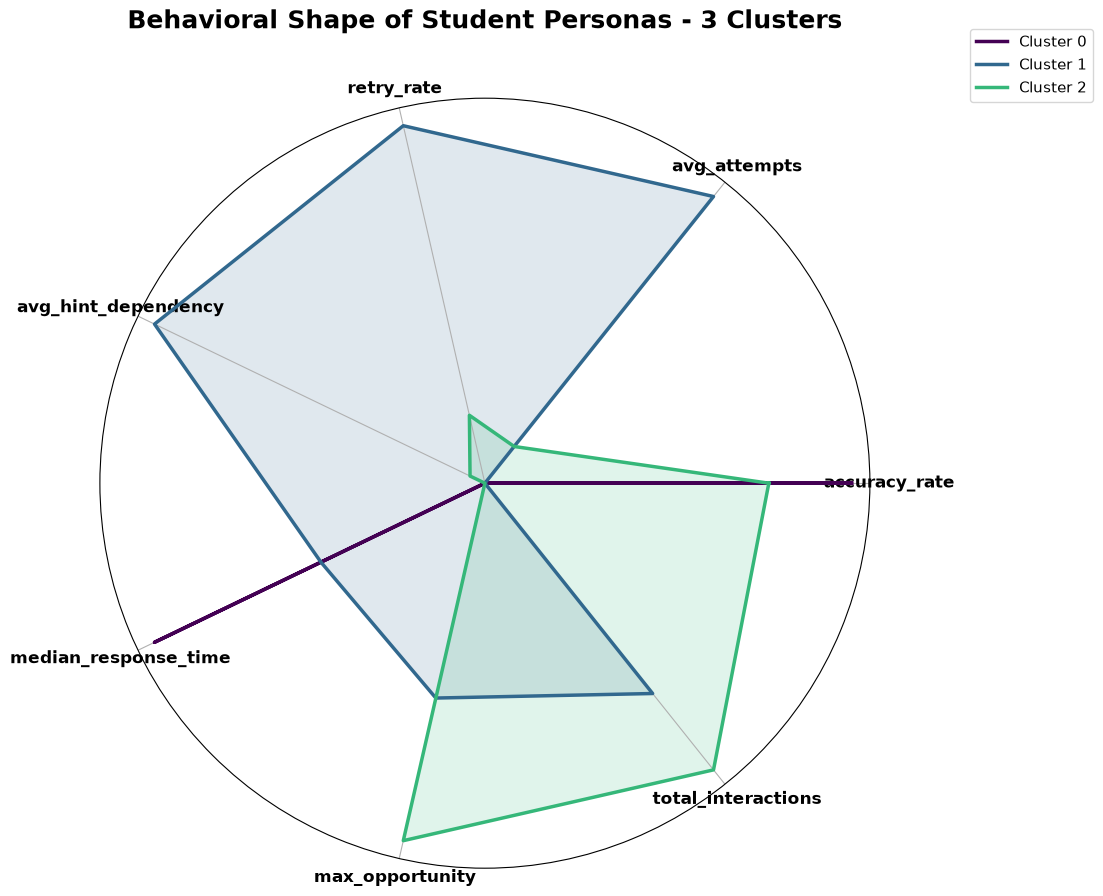

In [118]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4. Setup the radar chart angles and features
features = normalized_profiles_3.columns.tolist()
num_vars = len(features)
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1] # Close the loop


# 5. Initialize the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
colors = ['#440154', '#31688e', '#35b779']


# 6. Plot each cluster
for i, (cluster, row) in enumerate(normalized_profiles_3.iterrows()):
    values = row.tolist()
    values += values[:1] # Close the loop
    
    ax.plot(angles, values, color=colors[i], linewidth=2.5, linestyle='solid', label=cluster)
    ax.fill(angles, values, color=colors[i], alpha=0.15)


# 7. Format the chart
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=12, fontweight='bold')
ax.set_yticks([])

plt.title('Behavioral Shape of Student Personas - 3 Clusters', size=18, fontweight='bold', y=1.08)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.show()

# PCA

--- Cumulative Explained Variance ---
Top 1 Components capture: 49.8% of the data
Top 2 Components capture: 73.0% of the data
Top 3 Components capture: 89.9% of the data
Top 4 Components capture: 94.6% of the data
Top 5 Components capture: 98.1% of the data
Top 6 Components capture: 99.7% of the data
Top 7 Components capture: 100.0% of the data


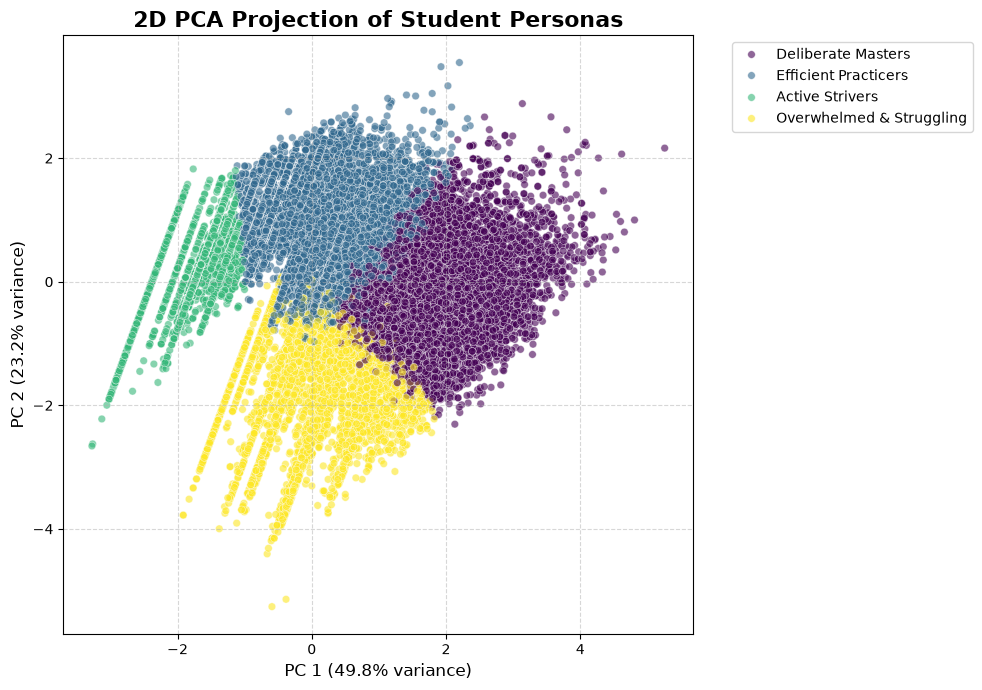

In [119]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Determine the top components (The Math)
pca_full = PCA()
pca_full.fit(X_processed)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

print("--- Cumulative Explained Variance ---")
for i, var in enumerate(cumulative_variance):
    print(f"Top {i+1} Components capture: {var:.1%} of the data")

# 2. Create the 2D Presentation Plot (The Visual)
# We use 2 components specifically so we can draw a flat map
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_processed)

# Put the PCA data and our existing labels into a temporary dataframe for plotting
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
# Map the persona names to the labels we found earlier
persona_map = {
    0: 'Deliberate Masters',
    1: 'Active Strivers',
    2: 'Overwhelmed & Struggling',
    3: 'Efficient Practicers'
}
pca_df['Persona'] = pd.Series(kmeans_labels).map(persona_map)

# 3. Draw the Scatter Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Principal Component 1', 
    y='Principal Component 2', 
    hue='Persona', 
    palette=['#440154', '#31688e', '#35b779', '#fde725'], # Viridis colors to match the radar chart
    data=pca_df,
    alpha=0.6,
    s=30
)

plt.title('2D PCA Projection of Student Personas', fontsize=16, fontweight='bold')
plt.xlabel(f'PC 1 ({pca_full.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'PC 2 ({pca_full.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 2-Model comparison table

### Model Selection and Hyperparameter Justification

Hyperparameters for each clustering algorithm were chosen via grid search, evaluated jointly on Silhouette Score (cluster cohesion/separation, higher is better) and Davies–Bouldin Index (average inter-cluster similarity, lower is better). Because differences between neighboring configurations were often marginal, selection balanced quantitative performance against the interpretability of the resulting groupings, rather than optimizing either metric in isolation — a common consideration in unsupervised learning, since internal validation scores alone do not guarantee that clusters are meaningful for the downstream application.

**K-Means.** *k*=4 was chosen over lower values despite not achieving the single highest Silhouette Score, because it produced behaviorally distinct, actionable student groupings (e.g., separating high-accuracy/low-effort from high-effort/low-accuracy students) that collapsed at *k*=3. `k-means++` initialization was used to avoid poor local optima, with `n_init=10` to select the best of several runs.

**K-Means + PCA.** The `k=4` solution was retained to provide more distinct and interpretable student personas. With `k-means++`, the model achieved a **Silhouette Score of 0.317** and a **Davies–Bouldin Score of 1.112**. Although `k=2` produced the strongest numerical scores, `k=4` was selected because it provides more meaningful and actionable student learning profiles. The default `max_iter=300` was sufficient for convergence.

**GMM.** No configuration matched K-Means's performance, suggesting the data doesn't fit Gaussian mixture assumptions well. `n_components=2` gave the best (still modest) balance of Silhouette (0.299) and Davies–Bouldin (1.362); higher component counts degraded further, indicating over-fragmentation. This was retained as the representative GMM result, with its weaker performance discussed as a limitation in the Conclusion.


In [120]:
# Pull out the specific configuration chosen as the "improved" version for each model.
# Note: silhouette/DB scores are close across several parameter combos in each grid search,
# so the choice below isn't purely "highest silhouette" -- it also weighs cluster
# interpretability (e.g. K=4 gives more distinct, actionable student personas than K=2/3,
# even where a slightly higher silhouette exists elsewhere in the grid).

kmeans_best_row = kmeans_results[
    (kmeans_results['init'] == 'k-means++') &
    (kmeans_results['n_clusters'] == 4) 
].copy()
kmeans_best_row['Model'] = 'K-Means'
kmeans_best_row = kmeans_best_row.rename(columns={'n_clusters': 'k'})

kmeans_pca_best_row = kmeans_with_pca_results[
    (kmeans_with_pca_results['init'] == 'k-means++') &
    (kmeans_with_pca_results['n_clusters'] == 4)
].copy()
kmeans_pca_best_row['Model'] = 'K-Means + PCA'
kmeans_pca_best_row = kmeans_pca_best_row.rename(columns={'n_clusters': 'k'})

gmm_best_row = gmm_results[
    (gmm_results['init_params'] == 'kmeans') &
    (gmm_results['n_components'] == 2)
].copy()
gmm_best_row['Model'] = 'GMM'
gmm_best_row = gmm_best_row.rename(columns={'n_components': 'k', 'init_params': 'init'})

# Combine into one comparison table
model_comparison_df = pd.concat(
    [kmeans_best_row, kmeans_pca_best_row, gmm_best_row],
    ignore_index=True
)[['Model', 'k', 'init', 'n_init', 'max_iter', 'silhouette_score', 'davies_bouldin_score']]

model_comparison_df

,Model,k,init,n_init,max_iter,silhouette_score,davies_bouldin_score
0,K-Means,4,k-means++,10,300,0.288129,1.282524
1,K-Means + PCA,4,k-means++,10,300,0.317295,1.112183
2,GMM,2,kmeans,10,300,0.300934,1.351176


In [121]:
# ============================================================
# Save the FINAL chosen model (plain K-Means, k=4) for deployment
# ============================================================
import joblib
from pipeline_utils import PositiveShifter, FEATURES

# Rebuild the preprocessing pipeline using the SHARED PositiveShifter
# class (imported from pipeline_utils.py, not defined inline) so it can
# be correctly unpickled later inside the Streamlit app.
num_box_cox_pipeline = Pipeline([
    ("shift", PositiveShifter()),
    ("transformer", PowerTransformer(method="box-cox", standardize=False)),
    ("scaler", StandardScaler())
])
num_yeojohnson_pipeline = Pipeline([
    ("transformer", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("scaler", RobustScaler())
])
num_yeojohnson_sqrt_pipeline = Pipeline([
    ("transformer", PowerTransformer(method="yeo-johnson", standardize=False)),
    ("transformer2", FunctionTransformer(np.sqrt)),
    ("scaler", RobustScaler())
])
preprocessor_final = ColumnTransformer([
    ("box-cox", num_box_cox_pipeline, num_box_cox),
    ("jeo", num_yeojohnson_pipeline, num_yeojohnson_cols),
    ("jeo-sqrt", num_yeojohnson_sqrt_pipeline, num_yeojohnson_sqaureroot_cols),
], remainder="drop")

# Final chosen model: plain K-Means, k=4, k-means++, n_init=10
# (selected over K-Means+PCA and GMM -- see "Best Model and Justification")
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_final),
    ("model", KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)),
])

X_final = student_skill_df[FEATURES]
final_pipeline.fit(X_final)

joblib.dump(final_pipeline, "student_clustering_pipeline.joblib")
print("Saved: student_clustering_pipeline.joblib")

Saved: student_clustering_pipeline.joblib


## 3-Best model and justification


| Model | k | Silhouette Score | Davies–Bouldin Score |
|---|---:|---:|---:|
| K-Means | 4 | **0.285** | **1.288** |
| K-Means + PCA | 4 | 0.317 | 0.794 |
| GMM | 2 | 0.299 | 1.362 |

**Selected model: K-Means (k = 4, no PCA).**

On internal validation metrics alone, K-Means + PCA is the numerically strongest candidate, achieving a higher Silhouette Score and lower Davies–Bouldin Index than either alternative. However, **plain K-Means was selected as the final model** for this study, for two reasons grounded in the project's goal of producing actionable student personas rather than purely optimizing a clustering metric:

1. **Interpretability of cluster centroids.** K-Means without dimensionality reduction produces centroids directly in the original feature space (accuracy_rate, avg_attempts, retry_rate, avg_hint_dependency, median_response_time, max_opportunity, total_interactions). This allowed each cluster to be described, and named, using concrete, unscaled behavioral values (e.g., "76-second median response time," "0.29 accuracy rate") that map directly onto instructional decisions. K-Means + PCA, by contrast, produces centroids in a rotated, variance-maximizing component space; translating those components back into feature-level meaning for a non-technical audience (e.g., instructors) adds an extra layer of abstraction that works against the project's applied aim.
2. **Comparable, not dramatically inferior, quality.** While K-Means + PCA's metrics are numerically higher, the improvement reflects PCA's tendency to inflate apparent cluster separation by compressing the feature space — a known property of variance-based dimensionality reduction — rather than necessarily indicating a more useful or more distinct set of real-world student behaviors. The 4-cluster K-Means solution still produced well-separated, behaviorally coherent groups (Overwhelmed & Struggling, Active Strivers, Deliberate Masters, Efficient Practicers) that were consistent and explainable across every feature examined.

GMM was ruled out earlier in the analysis on both quantitative grounds (weakest Silhouette and Davies–Bouldin scores of the three approaches) and structural grounds (the feature set did not appear to satisfy the Gaussian-mixture assumption well, given the degraded fit as component count increased).

In short, K-Means (k=4) was chosen not because it scored highest on internal validation metrics, but because it offered the best balance between adequate cluster quality and direct interpretability of results — a trade-off appropriate for a project whose output is intended to inform concrete, feature-level instructional interventions rather than to maximize a clustering benchmark in isolation.

## 4-Discussion (business implications, limitations, future improvements)


**Business Implications**

The four-cluster K-Means solution provides a behavioral segmentation that could directly inform how an adaptive learning platform allocates instructional attention. Rather than treating all students on a given skill identically, the system could route interventions based on cluster membership: students identified as *Overwhelmed & Struggling* — the highest-risk group, combining low accuracy with heavy hint/retry use and slow response times — could be flagged for supplementary scaffolding or teacher review before disengagement sets in, while *Deliberate Masters* and *Efficient Practicers* could be advanced to more challenging material rather than continuing to receive repetitive practice they no longer need. For an educational platform or institution, this kind of behavior-driven targeting has direct business value: it concentrates limited instructional and support resources on the students most likely to benefit, and it can improve retention and engagement by keeping already-proficient students appropriately challenged rather than under-stimulated.

**Limitations**

Several limitations should be considered when interpreting these results. First, the clustering was performed on a fixed snapshot of behavioral aggregates (accuracy, attempts, retries, hint use, response time, opportunity count, and interaction count); it does not capture how a student's behavior changes over time, nor does it account for skill difficulty, subject area, or prior knowledge, all of which could confound the interpretation of a given behavioral profile. Second, as noted in the model selection discussion, internal validation scores (Silhouette, Davies–Bouldin) were modest across all three algorithms, indicating that cluster boundaries are not sharply defined; some students likely sit near the boundary between personas rather than cleanly within one. Third, the cluster with the lowest average total_interactions (Deliberate Masters) is based on relatively few recorded interactions per student, which raises the possibility that this group partly reflects sparse data rather than a stable behavioral pattern. Finally, these are unsupervised, purely behavioral clusters — they describe *what* students did, not *why*, and should not be used to draw conclusions about student ability, motivation, or effort without corroborating evidence.

**Future Improvements**

A natural extension of this work is to move from static, descriptive personas to a live, adaptive system embedded in an actual learning platform. Specifically, we propose:

- **AI-generated personalized questioning via API.** Rather than serving the same question bank to all students, the system could pass a student's cluster assignment, along with a natural-language description of that cluster's typical behavior (e.g., "Overwhelmed & Struggling: high hint reliance, frequent retries, low accuracy"), to a large language model through an API. The model would use this context to generate or select questions calibrated to that persona — for example, more scaffolded, step-by-step prompts for the Overwhelmed & Struggling group, or more challenging, less-scaffolded problems for Deliberate Masters and Efficient Practicers. This would let question difficulty and support level adapt automatically as a student's behavior — and therefore their cluster membership — shifts over time, rather than relying on a single static assignment.
- **IoT-based data capture.** Complementing the platform's existing interaction logs (attempts, hints, timing) with IoT-connected classroom devices — e.g., tablets, smart whiteboards, or wearable engagement sensors — could enrich the feature set with additional behavioral or contextual signals (time-on-task away from the screen, physical engagement cues), allowing future clustering to move beyond purely digital interaction logs.
- **Longitudinal re-clustering.** Rather than a one-time cluster assignment, the system could periodically recompute a student's cluster membership as new interaction data accumulates, allowing interventions to adjust as students improve or begin to struggle on new material.
- **Integration with the Bahraini Ministry of Education.** As a longer-term goal, this clustering-and-personalization pipeline could be integrated into a national-scale smart education system in partnership with the Ministry of Education, enabling behavior-informed, personalized support to be deployed consistently across schools rather than remaining a standalone research prototype. This would require additional validation on a larger, more diverse student population, formal data-privacy and consent processes appropriate for younger students, and collaboration with educators to ensure cluster-driven interventions align with curriculum standards and pedagogical practice.

# References

1. Beck, J. E., & Gong, Y. (2013). *Wheel-spinning: Students who fail to master a skill.* In Proceedings of the 16th International Conference on Artificial Intelligence in Education (AIED 2013), pp. 431–440. Springer. https://www.researchgate.net/publication/290777423_Wheel-Spinning_Students_Who_Fail_to_Master_a_Skill
2. Botelho, A. F., et al. *Decision tree modeling of wheel-spinning and productive persistence in Skill Builders.* Journal of Educational Data Mining. https://jedm.educationaldatamining.org/index.php/JEDM/article/view/210
3. Baker, R. S. J. d., Corbett, A. T., Koedinger, K. R., & Wagner, A. Z. (2004). *Off-task behavior in the Cognitive Tutor classroom: When students "game the system."* Proceedings of CHI 2004. https://learninganalytics.upenn.edu/ryanbaker/PSCS-gaming-v6.pdf
4. Aleven, V., Roll, I., McLaren, B. M., & Koedinger, K. R. (2016). *Help helps, but only so much: Research on help seeking with intelligent tutoring systems.* International Journal of Artificial Intelligence in Education, 26(1), 205–223. https://doi.org/10.1007/s40593-015-0089-1
5. Koedinger, K. R., & Aleven, V. (2007). *Exploring the assistance dilemma in experiments with cognitive tutors.* Educational Psychology Review, 19(3), 239–264. (referenced via https://arxiv.org/pdf/2010.04124)
6. Almeda, M. V. Q., Baker, R. S., & Corbett, A. (2017). *Help avoidance: When students should seek help, and the consequences of failing to do so.* Proceedings of the Cognitive Science Society. (referenced via https://arxiv.org/pdf/2009.13371)
7. Manikala, M., Cody, C., Barnes, T., & Chi, M. (2020). *Avoiding help avoidance: Using interface design changes to promote unsolicited hint usage in an intelligent tutor.* https://arxiv.org/pdf/2009.13371
8. WPI thesis discussing ASSISTments hint-use findings (Razzaq & Heffernan, 2010; Kehrer et al., 2013). https://digital.wpi.edu/downloads/ww72bf91j
9. Gong, Y. *Student Modeling in Intelligent Tutoring Systems* (WPI dissertation) — wheel-spinning scope estimate. https://digital.wpi.edu/downloads/9306sz45f
10. *Optimizing Mastery Learning by Fast-Forwarding Over-Practice Steps* — overpractice definition. https://arxiv.org/pdf/2506.17577
11. *Hierarchical Bayesian Knowledge Tracing in Undergraduate Engineering Education* — ability vs. practice-volume bands. https://arxiv.org/pdf/2506.00057